# ESS 배터리 EDA — 다섯 질문과 배치 비교

원본 MAT 파일에서 필요한 데이터를 직접 읽고 **B1·B2·B3를 동일한 기준으로 비교**한다.
**위에서부터 실행하면 준비 → Q1~Q5 → 결과 저장**까지 이어진다. VS Code에서 `ESS Health (.venv)` 커널을 선택한다.

| 질문 | 확인할 출력 |
|---|---|
| 1. 수명 분포 | 150~2,300 공통 축 Histogram, 중앙값, 장·단수명 비율, 이상치 조사 표 |
| 2. QD 열화 | 원본/확대/초기 곡선, 초기 기울기, Knee 후보·민감도 |
| 3. ΔQ(V) | Q100−Q10, 장·단수명 곡선, 분산·로그 분산·최솟값 |
| 4. 충전 조건 | 정책별 수명·표본 수, 정책 C-rate, 실제 전류 패턴과 초기 기울기 |
| 5. 피처 선정 | 배치별 Pearson/Spearman, 배치 내 관계, VIF 제거 전후, 생성 이유 |

이 자료는 셀 충·방전 실험 데이터다. ESS 수명·열화 연구에 활용할 수 있지만, 계통 부하·요금·정전 정보가 없으므로 Peak Shaving·UPS의 경제 효과를 직접 검증하지는 않는다.

## 분석 전 알아둘 것과 실행 준비

- 기존 `.venv`의 `numpy`, `pandas`, `matplotlib`, `h5py`, `IPython`을 사용한다. 새 설치 셀을 매번 실행할 필요는 없다.
- `.mat`은 MATLAB v7.3/HDF5다. **Summary와 필요한 시계열만 선택**해서 읽는다.
- 아래 파일명으로 로컬 **B1/B2/B3**를 정의한다. `2018-04-03_varcharge...`는 두 셀의 별도 실험이어서 비교에서 제외한다.
- 로컬 B2는 **2018-02-20**다. [연구팀 로딩 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/Load%20Data.ipynb)의 수명 연장·배치 간 이어붙이기·제외 목록을 파일 출처 확인 없이 적용하지 않는다. 현재 단위는 물리적 독립성이 확인된 셀이 아니라 **파일 내 셀 기록**이다.
- 논문의 약 150~2,300사이클 범위는 Histogram 비교 축으로만 사용한다. 로컬 파일의 실제 최솟값·최댓값은 출력에서 다시 확인한다.

In [1]:
from pathlib import Path
import sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from IPython.display import display

%matplotlib inline
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
plt.rcParams.update({'font.size': 10, 'figure.figsize': (12, 5)})
root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
ROOT = next((p for p in root_candidates
             if (p / 'data' / '2017-05-12_batchdata_updated_struct_errorcorrect.mat').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('원본 MAT 파일이 있는 archive 프로젝트 내부에서 실행하세요.')
BATCH_ORDER = ['B1', 'B2', 'B3']
BATCH_FILES = {
    'B1': ROOT / 'data/2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'B2': ROOT / 'data/2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'B3': ROOT / 'data/2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
missing = [str(p) for p in BATCH_FILES.values() if not p.exists()]
if missing:
    raise FileNotFoundError('데이터 경로를 확인하세요: ' + ', '.join(missing))
print('Python:', sys.version.split()[0], '| Kernel:', sys.executable)
display(pd.DataFrame([{'batch_id': b, 'file': p.name, 'size_GiB': p.stat().st_size/2**30}
                      for b,p in BATCH_FILES.items()]).set_index('batch_id'))

Matplotlib is building the font cache; this may take a moment.


Python: 3.11.15 | Kernel: /Users/suyeong/Downloads/archive/.venv/bin/python


,file,size_GiB
batch_id,,
B1,2017-05-12_batchdata_updated_struct_errorcorre...,2.817549
B2,2018-02-20_batchdata_updated_struct_errorcorre...,1.883692
B3,2018-04-12_batchdata_updated_struct_errorcorre...,3.014403


### 데이터 구조와 분석 단위

| 계층 | 주요 값 | 사용 방식 |
|---|---|---|
| Descriptors | `cycle_life`, `charging_policy` | 셀당 한 행, 수명은 타깃 |
| Summary | 실제 `cycle`, `QD/QC`, `IR`, `Tmax/Tavg/Tmin`, `chargetime` | 관측 사이클별 통계·열화 |
| Cycles | `t`, `I`, `V`, `T`, `Qc/Qd`, `Qdlin` | 일부 초기 사이클의 전류와 방전곡선 |

`QD`는 Summary 방전 용량(Ah), `Qdlin`은 전압 격자에서 보간된 방전 용량이다. 로컬 데이터의 실제 `Vdlin`은 **3.5→2.0V, 1,000점**이며 3.6V까지라고 임의 생성하지 않는다.
연구의 수명 기준은 정격 1.1Ah의 80%(0.88Ah)이지만 아래에서는 **파일의 `cycle_life`를 그대로 타깃**으로 사용한다.
전체 곡선에서 발견한 Knee·마지막 용량·관측 길이를 초기 예측 입력에 넣지 않는다. [논문 Methods](https://petermattia.com/papers/Severson,%20Attia%20et%20al.%20-%202019%20-%20Data-driven%20prediction%20of%20battery%20cycle%20life%20before%20capacity%20degradation.pdf)

같은 `cell_id`가 각 파일에 다시 나오므로 고유 키 `cell_uid=B1_0`처럼 배치와 번호를 함께 사용한다.
수명 분포·타깃 상관은 셀당 한 번 집계한다. 사이클 행을 그대로 쓰면 오래 관측된 셀의 비중이 커진다.
수명 결측은 0이나 마지막 관측 사이클로 대체하지 않고 타깃 분석에서 제외한다.

In [2]:
FIELD_MAP = {'QD':'QDischarge', 'QC':'QCharge', 'IR':'IR',
             'Tmax':'Tmax', 'Tavg':'Tavg', 'Tmin':'Tmin', 'chargetime':'chargetime'}
frames, metadata_rows, structure_rows = [], [], []
for batch_id, path in BATCH_FILES.items():
    with h5py.File(path, 'r') as f:
        b = f['batch']
        refs = {k: b[k][()].reshape(-1) for k in ['summary','cycles','cycle_life','policy_readable']}
        assert all(len(v) == len(refs['summary']) for v in refs.values())
        for cell_id, sr in enumerate(refs['summary']):
            s = f[sr]
            cycle = s['cycle'][()].reshape(-1).astype(float)
            assert np.isfinite(cycle).all() and np.equal(cycle, np.floor(cycle)).all()
            cycle = cycle.astype(int)
            values = {k: s[v][()].reshape(-1).astype(float) for k,v in FIELD_MAP.items()}
            assert all(len(v) == len(cycle) for v in values.values())
            assert len(np.unique(cycle)) == len(cycle) and np.all(np.diff(cycle) > 0)
            raw_life = float(f[refs['cycle_life'][cell_id]][()].reshape(-1)[0])
            life = raw_life if np.isfinite(raw_life) and raw_life > 0 else np.nan
            policy = ''.join(chr(int(x)) for x in f[refs['policy_readable'][cell_id]][()].reshape(-1))
            uid = f'{batch_id}_{cell_id}'
            frame = pd.DataFrame(values).assign(batch_id=batch_id, cell_id=cell_id,
                cell_uid=uid, cycle=cycle, cycle_life=life, charging_policy=policy)
            frames.append(frame)
            metadata_rows.append({'batch_id':batch_id, 'cell_id':cell_id, 'cell_uid':uid,
                'cycle_life':life, 'charging_policy':policy,
                'observed_n':len(cycle), 'last_observed_cycle':int(cycle[-1])})
            cycle_group = f[refs['cycles'][cell_id]]
            structure_rows.append({'batch_id':batch_id,'cell_uid':uid,
                'summary_n':len(cycle), 'cycles_n':len(cycle_group['Qdlin'][()].reshape(-1)),
                'has_cycle_10':bool((cycle==10).any()), 'has_cycle_100':bool((cycle==100).any()),
                'cycle_equals_position_plus_1':bool(np.array_equal(cycle,np.arange(1,len(cycle)+1)))})
eda_raw = pd.concat(frames, ignore_index=True)
cells_all = pd.DataFrame(metadata_rows)
structure_checks = pd.DataFrame(structure_rows)
assert cells_all.cell_uid.is_unique
assert not eda_raw.duplicated(['cell_uid','cycle']).any()
assert structure_checks.summary_n.eq(structure_checks.cycles_n).all()
print('Summary:', eda_raw.shape, '| Cell records:', len(cells_all))
display(eda_raw.head())
display(cells_all.groupby('batch_id',sort=False).agg(
    cells=('cell_uid','size'), valid_life=('cycle_life','count'), policies=('charging_policy','nunique')))
display(structure_checks.groupby('batch_id',sort=False).agg(
    cells=('cell_uid','size'), has_10=('has_cycle_10','sum'), has_100=('has_cycle_100','sum'),
    position_matches=('cycle_equals_position_plus_1','sum')))

Summary: (116722, 13) | Cell records: 139


,QD,QC,IR,Tmax,Tavg,Tmin,chargetime,batch_id,cell_id,cell_uid,cycle,cycle_life,charging_policy
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,B1,0,B1_0,1,1190.0,3.6C(80%)-3.6C
1,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250,B1,0,B1_0,2,1190.0,3.6C(80%)-3.6C
2,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777,B1,0,B1_0,3,1190.0,3.6C(80%)-3.6C
3,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167,B1,0,B1_0,4,1190.0,3.6C(80%)-3.6C
4,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442,B1,0,B1_0,5,1190.0,3.6C(80%)-3.6C


,cells,valid_life,policies
batch_id,,,
B1,46,46,23
B2,47,39,20
B3,46,44,8


,cells,has_10,has_100,position_matches
batch_id,,,,
B1,46,46,46,46
B2,47,47,47,47
B3,46,46,46,46


### 품질 점검과 정제 비교 시나리오

NaN·0·극단값을 확인하고, **측정값 7개가 모두 0인 행만 제외**, 그 뒤 `IR≤0`만 결측으로 바꾼다.
용량·온도·충전시간의 극단값은 조사 표에 표시하며 원본을 자동 삭제하지 않는다. 그 값에 민감한 상관계수는 잠정 결과다.
`chargetime`은 원본 Summary 값을 쓰며 시간 범위·집계 정의가 검증되기 전에는 큰 값을 실제로 느린 충전이라고 단정하지 않는다.

In [3]:
measurements = list(FIELD_MAP)
placeholder = eda_raw[measurements].eq(0).all(axis=1)
eda_clean = eda_raw.loc[~placeholder].copy()
nonpositive_ir = eda_clean.IR <= 0
eda_clean.loc[nonpositive_ir,'IR'] = np.nan
quality_rows, extreme_rows = [], []
for batch in BATCH_ORDER:
    raw = eda_raw.loc[eda_raw.batch_id==batch]
    clean = eda_clean.loc[eda_clean.batch_id==batch]
    meta = cells_all.loc[cells_all.batch_id==batch]
    quality_rows.append({'batch_id':batch,'raw_rows':len(raw),'clean_rows':len(clean),
        'all_zero_rows':int(placeholder.loc[raw.index].sum()),
        'IR_nonpositive_raw':int((raw.IR<=0).sum()),'IR_missing_clean':int(clean.IR.isna().sum()),
        'missing_life_cells':int(meta.cycle_life.isna().sum())})
    for field in measurements:
        quality_rows.append({'batch_id':batch,'field':field,'NaN_raw':int(raw[field].isna().sum()),
            'zero_raw':int(raw[field].eq(0).sum()),'min_raw':raw[field].min(),'max_raw':raw[field].max()})
        for side, idx in [('min',raw[field].idxmin()),('max',raw[field].idxmax())]:
            extreme_rows.append({'batch_id':batch,'field':field,'side':side,
                'cell_uid':raw.loc[idx,'cell_uid'],'cycle':raw.loc[idx,'cycle'],'value':raw.loc[idx,field]})
quality_table = pd.DataFrame(quality_rows)
display(quality_table.loc[quality_table.field.isna()].dropna(axis=1,how='all').set_index('batch_id'))
display(quality_table.loc[quality_table.field.notna()].dropna(axis=1,how='all').set_index(['batch_id','field']))
display(pd.DataFrame(extreme_rows).loc[lambda x:x.field.isin(['QD','Tmax','Tmin','chargetime'])])
print('Target missing cells:')
display(cells_all.loc[cells_all.cycle_life.isna(), ['batch_id','cell_uid','charging_policy','last_observed_cycle']])

,raw_rows,clean_rows,all_zero_rows,IR_nonpositive_raw,IR_missing_clean,missing_life_cells
batch_id,,,,,,
B1,38811.0,38765.0,46.0,65.0,19.0,0.0
B2,26904.0,26904.0,0.0,4904.0,4904.0,8.0
B3,51007.0,51007.0,0.0,0.0,0.0,2.0


NaN_raw  zero_raw     min_raw      max_raw
batch_id field                                                 
B1       QD              0.0      46.0    0.000000     2.884085
         QC              0.0      46.0    0.000000     2.965895
         IR              0.0      65.0    0.000000     0.021789
         Tmax            0.0      46.0    0.000000    43.419384
         Tavg            0.0      46.0    0.000000    38.413597
         Tmin            0.0      46.0    0.000000    34.850979
         chargetime      0.0      46.0    0.000000   419.873355
B2       QD              0.0       0.0    0.825036     2.169301
         QC              0.0       0.0    0.828872     2.170981
         IR              0.0    4904.0    0.000000     0.027894
         Tmax            0.0       0.0   29.528460   400.000000
         Tavg            0.0       0.0   -8.657166    73.553779
         Tmin            0.0      24.0 -270.000000    34.871320
         chargetime      0.0       0.0    6.474445  3934.705167
B3       QD              0.0       0.0    0.880005     1.099805
         QC              0.0       0.0    0.880091     1.103005
         IR              0.0       0.0    0.009652     0.021188
         Tmax            0.0       0.0   31.209373    44.662853
         Tavg            0.0       0.0   31.002614    41.440286
         Tmin            0.0       0.0   28.032270    36.691219
         chargetime      0.0       0.0   10.024057    24.003052

,batch_id,field,side,cell_uid,cycle,value
0,B1,QD,min,B1_0,1,0.000000
1,B1,QD,max,B1_18,40,2.884085
6,B1,Tmax,min,B1_0,1,0.000000
7,B1,Tmax,max,B1_25,742,43.419384
10,B1,Tmin,min,B1_0,1,0.000000
11,B1,Tmin,max,B1_28,757,34.850979
12,B1,chargetime,min,B1_0,1,0.000000
13,B1,chargetime,max,B1_15,13,419.873355
14,B2,QD,min,B2_44,874,0.825036
15,B2,QD,max,B2_37,101,2.169301


Target missing cells:


,batch_id,cell_uid,charging_policy,last_observed_cycle
68,B2,B2_22,VarCharge-2C-100cycles,920
69,B2,B2_23,VarCharge-4C-100cycles,1152
81,B2,B2_35,VarCharge-6C-100cycles,423
82,B2,B2_36,VarCharge-8C-100cycles,280
83,B2,B2_37,3.6C(80%)-3.6C(SLOWCYCLE,101
84,B2,B2_38,4.8C(80%)-4.8C(SLOWCYCLE,101
85,B2,B2_39,3.6C(9%)-5C(SLOWCYCLE,434
86,B2,B2_40,5.2C(58%)-4C(SLOWCYCLE,459
116,B3,B3_23,4.8C(80%)-4.8C-newstructure,2189
125,B3,B3_32,4.8C(80%)-4.8C-newstructure,2237


### 초기 100사이클 피처 준비

예측 시점은 **실제 100사이클 관측 직후**로 가정한다. 셀별 초기 평균·QD 표준편차·기울기를 만든다.
정제 후 관측 개수와 사용 가능한 IR 개수도 확인한다. 기울기는 `QD = a + b×cycle`의 `b`이며 단위는 Ah/cycle다.
표준편차는 표본 기준(`ddof=1`), ΔQ 분산은 곡선 격자 전체 기준(`ddof=0`)으로 구분한다.
온도 평균/최고값은 열 부담, IR은 저항 상태, QD 평균은 초기 용량 수준, 변동·기울기는 초기 변화, 충전시간은 충전 조건의 후보 요약이다.

In [4]:
def aggregate_early(source):
    first100 = source.loc[(source.cycle>=1)&(source.cycle<=100)]
    agg = first100.groupby('cell_uid').agg(mean_IR=('IR','mean'), mean_QD=('QD','mean'),
        mean_Tavg=('Tavg','mean'), mean_Tmax=('Tmax','mean'),
        mean_chargetime=('chargetime','mean'), std_QD=('QD','std'))
    slopes = {}
    for uid, part in first100.groupby('cell_uid'):
        valid = part.loc[np.isfinite(part.QD)&(part.QD>0)]
        x,y = valid.cycle.to_numpy(float), valid.QD.to_numpy(float)
        slopes[uid] = float(np.polyfit(x,y,1)[0]) if len(x)>=20 and np.ptp(x)>=50 else np.nan
    agg['early_QD_slope'] = pd.Series(slopes)
    return cells_all.set_index('cell_uid')[['batch_id','cycle_life']].join(agg)

early_raw = aggregate_early(eda_raw)
early_clean = aggregate_early(eda_clean)
early_coverage = eda_clean.loc[eda_clean.cycle<=100].groupby('cell_uid').agg(
    early_n=('cycle','size'), early_IR_n=('IR','count'), max_early_cycle=('cycle','max'))
early_coverage = cells_all.set_index('cell_uid')[['batch_id','cycle_life']].join(early_coverage)
assert early_clean.index.is_unique and len(early_clean)==len(cells_all)
display(early_coverage.groupby('batch_id',sort=False).agg(
    min_early_n=('early_n','min'), median_early_n=('early_n','median'),
    min_IR_n=('early_IR_n','min'), complete_cycle_100=('max_early_cycle',lambda x:int((x==100).sum()))))
display(early_clean.head())
valid_lives = cells_all.cycle_life.dropna()
life_norm = Normalize(valid_lives.min(),valid_lives.max())
life_cmap = plt.get_cmap('viridis')

,min_early_n,median_early_n,min_IR_n,complete_cycle_100
batch_id,,,,
B1,99,99.0,98,46
B2,100,100.0,0,47
B3,100,100.0,100,46


,batch_id,cycle_life,mean_IR,mean_QD,mean_Tavg,mean_Tmax,mean_chargetime,std_QD,early_QD_slope
cell_uid,,,,,,,,,
B1_0,B1,1190.0,0.016643,1.080597,31.603747,35.376748,13.384231,0.046562,-0.000207
B1_1,B1,1179.0,0.016922,1.081247,31.330314,34.160655,13.374696,0.001191,0.000006
B1_2,B1,1177.0,0.016769,1.085371,31.479584,34.544644,13.378886,0.001026,0.000010
B1_3,B1,1226.0,0.016311,1.084949,29.942199,30.662263,12.053277,0.001096,0.000017
B1_4,B1,1227.0,0.016669,1.082844,31.448884,34.382516,12.053314,0.001095,0.000019


## 1. Cycle life 분포 — 배치마다 무엇이 다른가?

배터리당 한 행인 `cells_all`로 평균·중앙값·IQR을 계산한다. 장수명은 **1,000 초과**, 단수명은
**500 미만**이며 비율의 분모는 해당 배치의 **유효 수명 라벨 수**다. 수명 결측은 별도로 표시하고
0으로 대체하지 않는다. 배치별/전체 그림은 같은 150–2,300사이클 축과 50사이클 bin을 사용한다.

전체 합계는 로컬 세 파일의 기술통계다. 배치별 충전 정책·실험 조건 차이와 파일 간 물리적 셀
중복 가능성이 있으므로 독립 표본의 검증 결과로 해석하지 않는다.

In [5]:
q1_life = cells_all.copy()
q1_life['cycle_life'] = pd.to_numeric(q1_life['cycle_life'], errors='coerce')
q1_life.loc[~np.isfinite(q1_life.cycle_life) | (q1_life.cycle_life <= 0), 'cycle_life'] = np.nan
assert not q1_life.cell_uid.duplicated().any(), '배터리당 한 행인지 확인하세요.'

q1_stats_rows, q1_fence_rows = [], []
for q1_name in [*BATCH_ORDER, 'All files']:
    q1_part = q1_life if q1_name == 'All files' else q1_life.loc[q1_life.batch_id == q1_name]
    q1_values = q1_part.cycle_life.dropna()
    q1_n = len(q1_values)
    q1_q25, q1_q75 = q1_values.quantile([.25, .75]) if q1_n else (np.nan, np.nan)
    q1_iqr = q1_q75 - q1_q25
    q1_stats_rows.append({
        'batch': q1_name, 'total_cells': len(q1_part), 'valid_life': q1_n,
        'missing_life': int(q1_part.cycle_life.isna().sum()),
        'mean': q1_values.mean(), 'median': q1_values.median(),
        'min': q1_values.min(), 'Q1': q1_q25, 'Q3': q1_q75, 'max': q1_values.max(),
        'short_n': int((q1_values < 500).sum()), 'long_n': int((q1_values > 1000).sum()),
        'short_percent': (q1_values < 500).mean()*100 if q1_n else np.nan,
        'long_percent': (q1_values > 1000).mean()*100 if q1_n else np.nan,
        'outside_plot_range': int((~q1_values.between(150, 2300)).sum()),
    })
    if q1_name != 'All files':
        q1_fence_rows.append({'batch_id': q1_name, 'lower_fence': q1_q25 - 1.5*q1_iqr,
                             'upper_fence': q1_q75 + 1.5*q1_iqr})
q1_stats = pd.DataFrame(q1_stats_rows).set_index('batch')
q1_fences = pd.DataFrame(q1_fence_rows)
display(q1_stats[['total_cells','valid_life','missing_life','mean','median','min','Q1','Q3','max']].round(2))
display(q1_stats[['short_n','short_percent','long_n','long_percent','outside_plot_range']].round(2))
print('short/long 비율 분모: 유효 수명 라벨; 500과 1000은 middle에 포함합니다.')

,total_cells,valid_life,missing_life,mean,median,min,Q1,Q3,max
batch,,,,,,,,,
B1,46,46,0,844.72,858.5,534.0,703.25,914.25,1227.0
B2,47,39,8,565.74,472.0,392.0,439.50,508.50,1186.0
B3,46,44,2,1059.66,1005.5,541.0,828.00,1155.25,1935.0
All files,139,129,10,833.69,828.0,392.0,559.00,1017.00,1935.0


,short_n,short_percent,long_n,long_percent,outside_plot_range
batch,,,,,
B1,0,0.00,10,21.74,0
B2,28,71.79,3,7.69,0
B3,0,0.00,23,52.27,0
All files,28,21.71,36,27.91,0


short/long 비율 분모: 유효 수명 라벨; 500과 1000은 middle에 포함합니다.


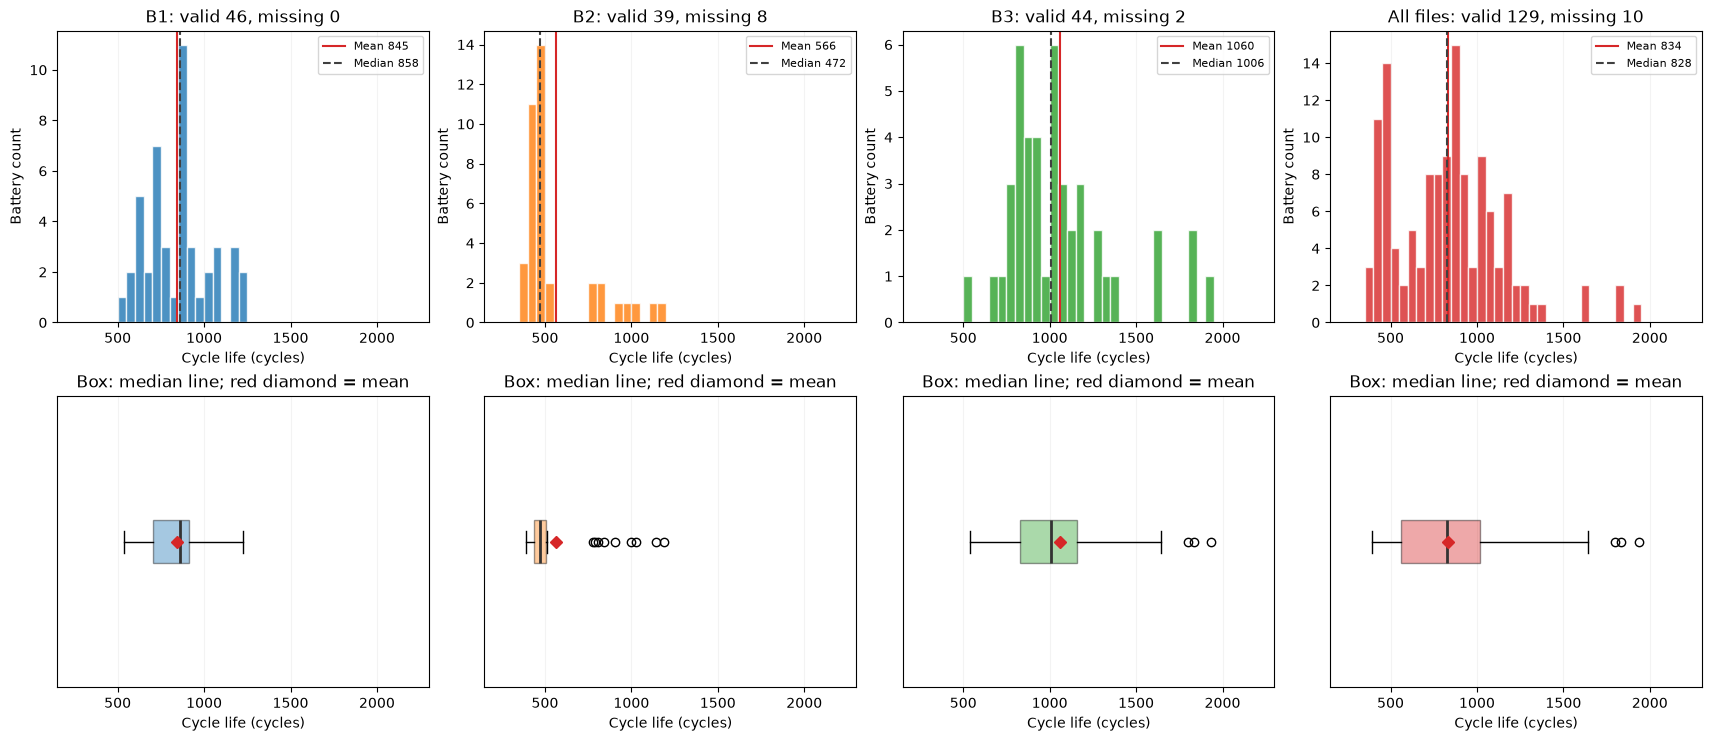

In [6]:
q1_bins = np.arange(150, 2300 + 50, 50)
fig, q1_axes = plt.subplots(2, 4, figsize=(17, 7.3), constrained_layout=True)
for q1_col, q1_name in enumerate([*BATCH_ORDER, 'All files']):
    q1_part = q1_life if q1_name == 'All files' else q1_life.loc[q1_life.batch_id == q1_name]
    q1_values = q1_part.cycle_life.dropna().to_numpy()
    q1_hist, q1_box = q1_axes[:, q1_col]
    if len(q1_values):
        q1_hist.hist(q1_values, bins=q1_bins, color=f'C{q1_col}', edgecolor='white', alpha=.8)
        q1_hist.axvline(np.mean(q1_values), color='C3', label=f'Mean {np.mean(q1_values):.0f}')
        q1_hist.axvline(np.median(q1_values), color='0.25', linestyle='--',
                       label=f'Median {np.median(q1_values):.0f}')
        q1_box.boxplot(q1_values, orientation='horizontal', showmeans=True, patch_artist=True,
                       boxprops={'facecolor': f'C{q1_col}', 'alpha': .4},
                       meanprops={'marker': 'D', 'markerfacecolor': 'C3', 'markeredgecolor': 'C3'},
                       medianprops={'color': '0.2', 'linewidth': 2})
        q1_hist.legend(fontsize=8)
    else:
        q1_hist.text(.5, .5, 'No valid life labels', transform=q1_hist.transAxes, ha='center')
    for q1_ax in (q1_hist, q1_box):
        q1_ax.set_xlim(150, 2300)
        q1_ax.set_xlabel('Cycle life (cycles)')
        q1_ax.grid(axis='x', alpha=.15)
    q1_hist.set(title=f'{q1_name}: valid {len(q1_values)}, missing {q1_part.cycle_life.isna().sum()}',
                ylabel='Battery count')
    q1_box.set(title='Box: median line; red diamond = mean', yticks=[])
plt.show()

In [7]:
# 수명 극단 후보의 정책과 초기 신호를 함께 점검한다. 자동 제거하거나 원인을 확정하지 않는다.
q1_investigate = q1_life.merge(q1_fences, on='batch_id', validate='many_to_one')
q1_investigate['short_lt500'] = q1_investigate.cycle_life < 500
q1_investigate['IQR_candidate'] = ((q1_investigate.cycle_life < q1_investigate.lower_fence) |
                                  (q1_investigate.cycle_life > q1_investigate.upper_fence))
q1_investigate['shortest3_in_batch'] = q1_investigate.groupby('batch_id').cycle_life.rank(
    method='first', ascending=True).le(3)
q1_signal_cols = ['mean_QD','std_QD','early_QD_slope','mean_IR','mean_Tavg','mean_Tmax','mean_chargetime']
q1_signals = early_clean[q1_signal_cols].copy()
q1_signals.index.name = 'cell_uid'
q1_investigate = q1_investigate.merge(q1_signals.reset_index(), on='cell_uid',
                                     how='left', validate='one_to_one')
q1_selected = q1_investigate.loc[q1_investigate[['short_lt500','IQR_candidate','shortest3_in_batch']].any(axis=1)]
display(q1_selected[['batch_id','cell_uid','cycle_life','charging_policy',
                     'short_lt500','IQR_candidate','shortest3_in_batch',*q1_signal_cols]]
        .sort_values(['batch_id','cycle_life']).round(5))

q1_group_signals = q1_investigate.loc[q1_investigate.cycle_life.notna()].copy()
q1_group_signals['life_group'] = np.select(
    [q1_group_signals.cycle_life < 500, q1_group_signals.cycle_life > 1000],
    ['Short (<500)', 'Long (>1000)'], default='Middle (500–1000)')
q1_group_table = q1_group_signals.groupby(['batch_id','life_group']).agg(
    n=('cell_uid','size'), median_life=('cycle_life','median'),
    median_QD=('mean_QD','median'), median_QD_std=('std_QD','median'),
    median_QD_slope=('early_QD_slope','median'), median_IR=('mean_IR','median'),
    median_Tavg=('mean_Tavg','median'), median_chargetime=('mean_chargetime','median'))
display(q1_group_table.round(5))
for q1_name in BATCH_ORDER:
    if not ((q1_group_signals.batch_id == q1_name) & (q1_group_signals.life_group == 'Short (<500)')).any():
        print(f'{q1_name}: Short (<500) 집단 없음 — 해당 집단의 초기 신호를 계산하지 않습니다.')

q1_policy = q1_investigate.groupby(['batch_id','charging_policy'], dropna=False).agg(
    total_cells=('cell_uid','size'), valid_life=('cycle_life','count'),
    median_life=('cycle_life','median'), short_n=('short_lt500','sum'),
    IQR_candidates=('IQR_candidate','sum'))
q1_policy['short_percent_valid'] = q1_policy.short_n.div(q1_policy.valid_life.where(q1_policy.valid_life > 0))*100
display(q1_policy.sort_values(['short_n','median_life'], ascending=[False,True]).round(3))

,batch_id,cell_uid,cycle_life,charging_policy,short_lt500,IQR_candidate,shortest3_in_batch,mean_QD,std_QD,early_QD_slope,mean_IR,mean_Tavg,mean_Tmax,mean_chargetime
20,B1,B1_20,534.0,5.4C(80%)-5.4C,False,False,True,1.06984,0.00418,-0.00014,0.01521,32.15292,34.92835,9.02721
21,B1,B1_21,559.0,5.4C(80%)-5.4C,False,False,True,1.08223,0.00261,-0.00008,0.01509,33.13697,36.94893,8.98727
45,B1,B1_45,599.0,8C(35%)-3.6C,False,False,True,1.08716,0.00077,-0.00001,0.01667,33.00055,36.69643,10.25727
65,B2,B2_19,392.0,6C(60%)-3C,True,False,True,1.09472,0.00286,0.00002,0.01672,32.76991,36.54390,10.17377
52,B2,B2_6,393.0,3.6C(9%)-5C,True,False,True,1.09291,0.00296,0.00006,0.01604,33.81745,39.79550,10.17929
61,B2,B2_15,396.0,3.6C(9%)-5C,True,False,True,1.07498,0.00309,0.00009,0.01631,32.86231,36.06956,10.17306
67,B2,B2_21,408.0,6C(60%)-3C,True,False,False,1.10109,0.01105,0.00004,0.01720,33.59820,38.65188,10.17472
76,B2,B2_30,412.0,5.6C(26%)-4.5C,True,False,False,1.09300,0.00346,-0.00008,0.01689,33.81004,37.33980,49.43362
51,B2,B2_5,416.0,3.6C(30%)-6C,True,False,False,1.08803,0.01293,-0.00019,0.01531,33.01550,37.64690,10.19851
48,B2,B2_2,424.0,5.2C(50%)-4.25C,True,False,False,1.07466,0.01124,-0.00000,0.01646,33.17757,37.42764,10.17503


n  median_life  median_QD  median_QD_std  median_QD_slope  median_IR  median_Tavg  median_chargetime
batch_id life_group                                                                                                              
B1       Long (>1000)       10       1125.5    1.08265        0.00104          0.00001    0.01671     31.54167           12.10989
         Middle (500–1000)  36        772.5    1.08219        0.00083         -0.00001    0.01659     33.02232           10.74301
B2       Long (>1000)        3       1140.0    1.07061        0.00322         -0.00007    0.01497     33.91860           10.03956
         Middle (500–1000)   8        800.0    1.09687        0.00248         -0.00003    0.01540     33.40167           10.10509
         Short (<500)       28        449.5    1.09915        0.00308          0.00003    0.01668     32.93725           10.17507
B3       Long (>1000)       23       1155.0    1.06769        0.00074         -0.00000    0.01538     34.74383           10.04354
         Middle (500–1000)  21        828.0    1.06741        0.00084         -0.00000    0.01531     34.05078           10.04322

B1: Short (<500) 집단 없음 — 해당 집단의 초기 신호를 계산하지 않습니다.
B3: Short (<500) 집단 없음 — 해당 집단의 초기 신호를 계산하지 않습니다.


total_cells  valid_life  median_life  short_n  IQR_candidates  short_percent_valid
batch_id charging_policy                                                                                                
B2       5.6C(26%)-4.5C                         6           6        446.0        6               0                100.0
         5.2C(50%)-4.25C                        5           5        449.0        5               0                100.0
         5.2C(58%)-4C                           4           4        483.0        4               0                100.0
         4.8C(80%)-4.8C                         5           5        492.0        3               0                 60.0
         3.6C(9%)-5C                            2           2        394.5        2               0                100.0
         6C(60%)-3C                             2           2        400.0        2               0                100.0
         3.6C(30%)-6C                           2           2        421.0        2               0                100.0
         4.65C(69%)-6C                          2           2        452.0        2               0                100.0
         4.65C(44%)-5C                          2           2        482.5        2               0                100.0
B1       5.4C(80%)-5.4C                         2           2        546.5        0               0                  0.0
         8C(35%)-3.6C                           2           2        607.5        0               0                  0.0
         7C(40%)-3.6C                           2           2        621.0        0               0                  0.0
B3       3.7C(31%)-5.9C-newstructure            3           3        667.0        0               0                  0.0
B1       7C(40%)-3C                             2           2        676.0        0               0                  0.0
         8C(25%)-3.6C                           2           2        676.5        0               0                  0.0
         7C(30%)-3.6C                           2           2        722.5        0               0                  0.0
         5.4C(70%)-3C                           2           2        739.5        0               0                  0.0
         6C(60%)-3C                             2           2        744.0        0               0                  0.0
         4.8C(80%)-4.8C                         2           2        753.0        0               0                  0.0
         6C(50%)-3.6C                           2           2        792.5        0               0                  0.0
         5.4C(60%)-3C                           2           2        799.5        0               0                  0.0
B2       4.8C(80%)-4.8C-newstructure            3           3        809.0        0               3                  0.0
B1       5.4C(50%)-3C                           2           2        847.0        0               0                  0.0
         6C(40%)-3.6C                           2           2        856.0        0               0                  0.0
         5.4C(60%)-3.6C                         2           2        859.5        0               0                  0.0
B3       5.9C(60%)-3.1C-newstructure            2           2        866.5        0               0                  0.0
         5.9C(15%)-4.6C-newstructure            2           2        867.0        0               0                  0.0
B1       6C(50%)-3C                             2           2        888.5        0               0                  0.0
B3       5.6C(36%)-4.3C-newstructure            8           8        890.5        0               0                  0.0
B1       5.4C(50%)-3.6C                         2           2        899.5        0               0                  0.0
B2       5.2C(58%)-4C-newstructure              3           3        904.0        0               3                  0.0
B1       6C(40%)-3C                          

**해석:** IQR 경계 밖의 셀과 짧은 수명 셀은 조사 후보다. 초기 용량·IR·온도·충전 시간 및 정책의
차이가 함께 보이는지 살피되, 정책 효과나 측정 오류를 원인으로 확정하지 않는다. 결측 IR 등으로
신호별 유효 표본 수가 다를 수 있다. 초기 평균/기울기에 남아 있는 스파이크도 별도 점검해야 한다.
박스플롯 수염은 최솟값·최댓값과 항상 같지 않으며 평균과 중앙값이 비슷해도 편향이 없다는 뜻은 아니다.

### 1-1. Batch 1·2 수명 분포 직접 비교

현재 모델링에서는 **Batch 1을 학습·검증**, **Batch 2를 테스트**에 사용한다.
두 배치의 배터리 수명 분포가 얼마나 다른지 한 화면에서 비교해 보자.

여기서 사이클 분포는 배터리마다 하나씩 있는 **`cycle_life`(수명 라벨)**의 분포다.
측정 행의 `cycle` 번호나 기록된 사이클 행 수와는 구분한다.
위에서 원본 MAT로 만든 `q1_life`를 사용하며, 유효한 양수 수명만 통계에 포함한다.
피처가 유효한지에 따른 모델링 제외 조건은 아직 적용하지 않는다.

In [8]:
# 1) Batch 1·2의 수명 요약표: 배터리당 한 행, 수명 결측은 별도 표시
b12_life = q1_life.loc[q1_life.batch_id.isin(['B1', 'B2'])].copy()
b12_values = {
    batch: b12_life.loc[b12_life.batch_id.eq(batch), 'cycle_life'].dropna().to_numpy(dtype=float)
    for batch in ['B1', 'B2']
}
if any(len(values) == 0 for values in b12_values.values()):
    raise ValueError('Batch 1·2 모두 유효한 수명 라벨이 있어야 비교할 수 있습니다.')

b12_summary = q1_stats.loc[['B1', 'B2'], [
    'total_cells', 'valid_life', 'missing_life', 'min', 'Q1', 'median', 'mean', 'Q3', 'max',
    'short_n', 'short_percent',
]].rename(columns={
    'total_cells': '전체 셀 수', 'valid_life': '유효 수명 셀 수', 'missing_life': '수명 결측 셀 수',
    'min': '최솟값', 'Q1': '25% 분위수', 'median': '중앙값', 'mean': '평균',
    'Q3': '75% 분위수', 'max': '최댓값',
    'short_n': '500 미만 셀 수', 'short_percent': '500 미만 비율(%)',
}).rename(index={'B1': 'Batch 1', 'B2': 'Batch 2'})
b12_summary.index.name = '배치'
display(b12_summary.round(2))

# B1에서 관찰한 최저 수명보다 짧은 B2 셀은 얼마나 되는가?
b12_b1_min = float(b12_values['B1'].min())
b12_b2_below_min = int((b12_values['B2'] < b12_b1_min).sum())
b12_b2_below_pct = 100 * b12_b2_below_min / len(b12_values['B2'])
b12_median_gap = float(np.median(b12_values['B2']) - np.median(b12_values['B1']))
print(f'중앙값 차이 (Batch 2 − Batch 1): {b12_median_gap:+.1f} 사이클')
print(f'Batch 1의 최저 수명: {b12_b1_min:g} 사이클')
print(f'그보다 짧은 Batch 2 셀: {b12_b2_below_min}/{len(b12_values["B2"])}개 '
      f'({b12_b2_below_pct:.2f}%)')

,전체 셀 수,유효 수명 셀 수,수명 결측 셀 수,최솟값,25% 분위수,중앙값,평균,75% 분위수,최댓값,500 미만 셀 수,500 미만 비율(%)
배치,,,,,,,,,,,
Batch 1,46,46,0,534.0,703.25,858.5,844.72,914.25,1227.0,0,0.00
Batch 2,47,39,8,392.0,439.50,472.0,565.74,508.50,1186.0,28,71.79


중앙값 차이 (Batch 2 − Batch 1): -386.5 사이클
Batch 1의 최저 수명: 534 사이클
그보다 짧은 Batch 2 셀: 30/39개 (76.92%)


**코드 설명과 표 읽는 법**

- `b12_values`에는 수명 결측을 제외한 Batch 1·2의 수명 값만 들어간다. 결측을 0으로 바꾸지 않는다.
- **중앙값**은 각 배치의 가운데 수명이다. `Batch 2 − Batch 1`이 음수면 Batch 2의 중앙값이 더 짧다.
- **25%·75% 분위수** 사이에 가운데 50%의 셀이 들어간다. 두 배치의 중앙값과 이 구간을 함께 비교한다.
- **500 미만 비율**은 `500 미만 셀 수 ÷ 유효 수명 셀 수 × 100`이다. 500은 비교를 위한 참고 기준이다.
- 마지막 출력은 **Batch 1의 최저 수명보다 짧은 Batch 2 셀의 비율**이다. 이 셀들은 수명 값이
  Batch 1에서 관찰한 범위 아래에 있다. 이 값만으로 초기 피처도 학습 범위 밖이라고 단정할 수는 없다.

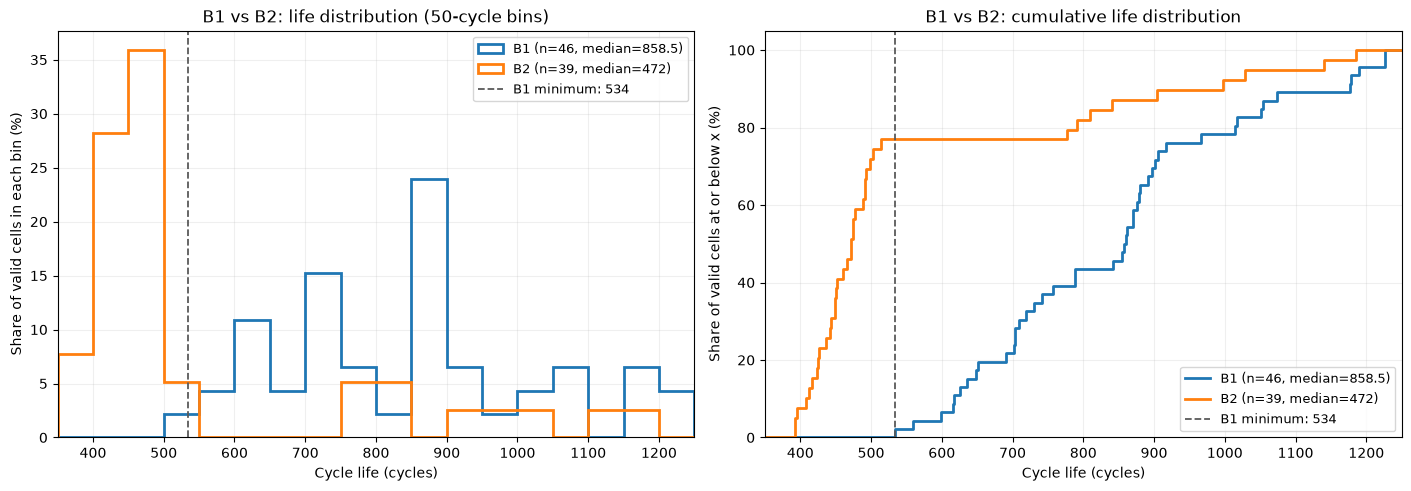

In [9]:
# 2) 동일한 50사이클 구간으로 비율 히스토그램과 누적분포를 비교
b12_all_values = np.concatenate(list(b12_values.values()))
b12_bin_width = 50
b12_lower = np.floor(b12_all_values.min() / b12_bin_width) * b12_bin_width
b12_upper = np.ceil(b12_all_values.max() / b12_bin_width) * b12_bin_width
if b12_upper <= b12_lower:
    b12_upper = b12_lower + b12_bin_width
b12_bins = np.arange(b12_lower, b12_upper + b12_bin_width, b12_bin_width)

b12_fig, b12_axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
for batch, color in [('B1', 'C0'), ('B2', 'C1')]:
    values = b12_values[batch]
    label = f'{batch} (n={len(values)}, median={np.median(values):g})'
    # 배치별 막대 높이의 합이 100%가 되도록 정규화한다.
    weights = np.full(len(values), 100.0 / len(values))
    b12_axes[0].hist(values, bins=b12_bins, weights=weights, histtype='step',
                     linewidth=2, color=color, label=label)
    # ECDF: x 사이클 이하인 배터리의 비율. 마지막 값은 반드시 100%다.
    sorted_values = np.sort(values)
    cumulative_percent = np.arange(1, len(values) + 1) / len(values) * 100
    b12_axes[1].step(np.r_[b12_lower, sorted_values, b12_upper],
                     np.r_[0, cumulative_percent, 100], where='post',
                     linewidth=2, color=color, label=label)

b12_axes[0].set(title='B1 vs B2: life distribution (50-cycle bins)',
                ylabel='Share of valid cells in each bin (%)')
b12_axes[1].set(title='B1 vs B2: cumulative life distribution',
                ylabel='Share of valid cells at or below x (%)', ylim=(0, 105))
for ax in b12_axes:
    ax.axvline(b12_b1_min, color='0.35', linestyle='--', linewidth=1.3,
               label=f'B1 minimum: {b12_b1_min:g}')
    ax.set(xlabel='Cycle life (cycles)', xlim=(b12_lower, b12_upper))
    ax.grid(alpha=.2)
    ax.legend(fontsize=9, loc='upper right' if ax is b12_axes[0] else 'lower right')
plt.show()

**코드 설명과 그래프 읽는 법**

왼쪽은 **비율 히스토그램**이다. 두 배치에 같은 50사이클 구간을 적용하고, 각 배치의 전체를
100%로 맞췄다. 표본 수가 다른 배치도 비교할 수 있다. 막대 대신 선으로 테두리를 그려
두 분포가 겹치는 부분도 보이게 했다. 구간별 비율의 합이 100%이며, 확률밀도 그래프는 아니다.

오른쪽은 **누적분포(ECDF)**다. x축에서 수명을 하나 고르면 y축은 그 수명 **이하**인 셀의
비율을 뜻한다. 같은 x에서 Batch 2의 선이 더 높으면 그 기준보다 짧게 사는 셀이 더 많다.
표의 `500 미만`은 `< 500`, 누적분포는 `≤ x`이므로 경계값이 있는 경우 두 비율은 다를 수 있다.
점선은 Batch 1의 최저 수명이며, 두 그래프의 범위에는 유효 수명 값이 모두 포함되어 있다.

**모델 결과와 연결하기:** Batch 2가 짧은 수명 쪽에 몰려 있으면, Batch 1에서 배운 모델이
Batch 2의 수명을 길게 예측하는지 실제값·예측값과 잔차로 확인한다. 짧은 실제 수명은 같은
사이클 오차에도 MAPE가 더 크게 나온다 (`|예측−실제| ÷ 실제 × 100`).
이 분포 비교는 배치 차이를 보여주지만, 큰 성능 Gap이 피처 선택 때문인지 확정하는 결과는 아니다.

## 2. 열화 곡선 — 일정한 감소인가, 후반 가속인가?

먼저 원본 범위와 일반 용량 범위를 나란히 보고 초기 100사이클을 확대한다. 확대 범위 밖 측정값은 원본에서 남아 있다.
색은 실제 수명에 연결하고 수명 결측 셀은 회색으로 표시한다. 0.88Ah는 논문 정격 용량 기준의 참고선이다.

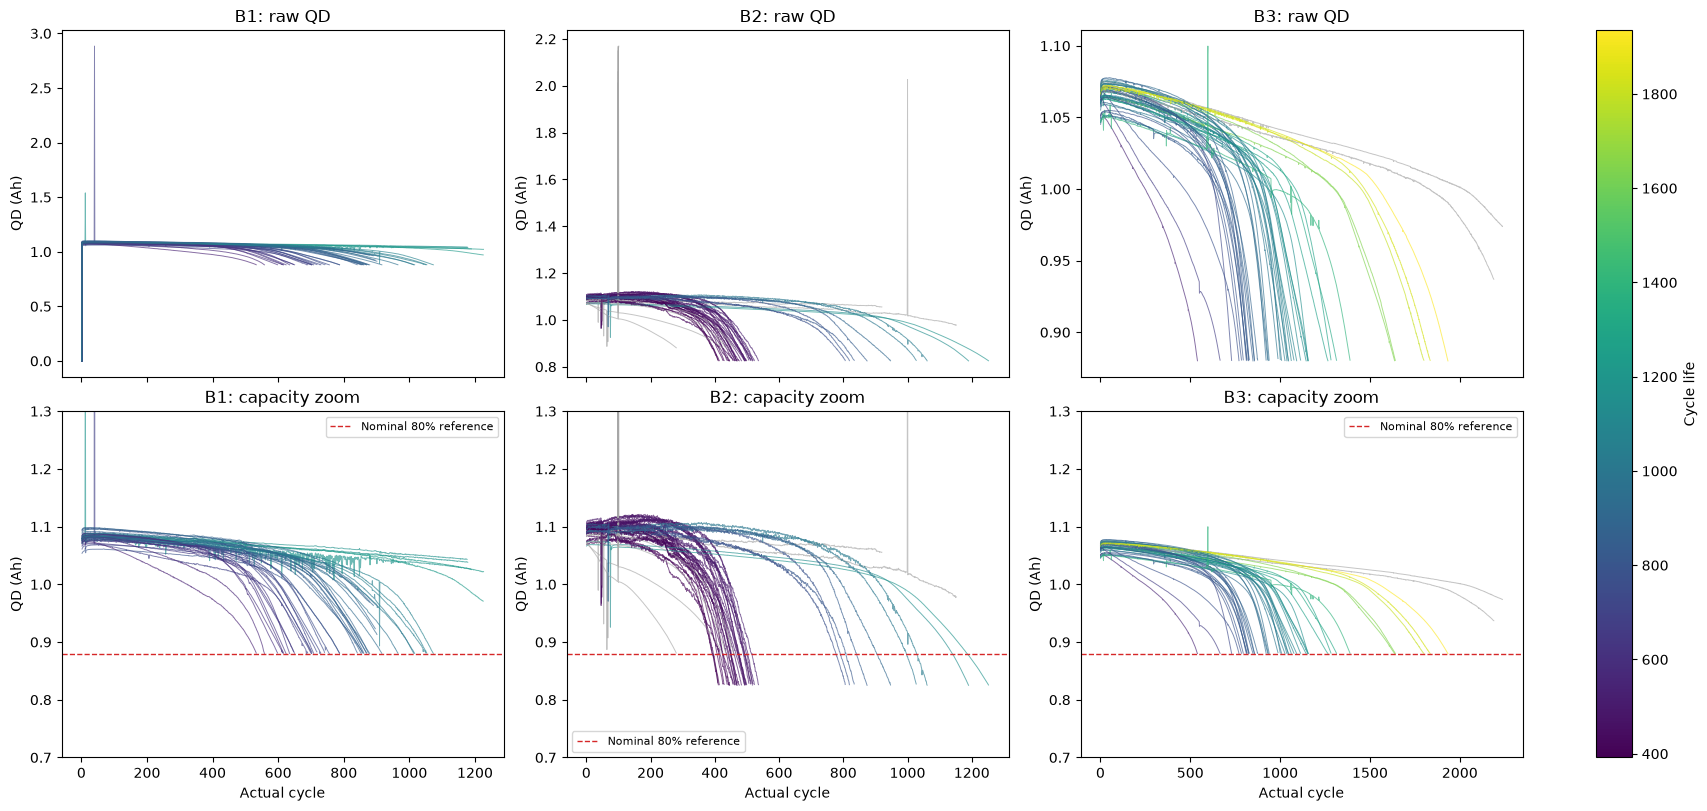

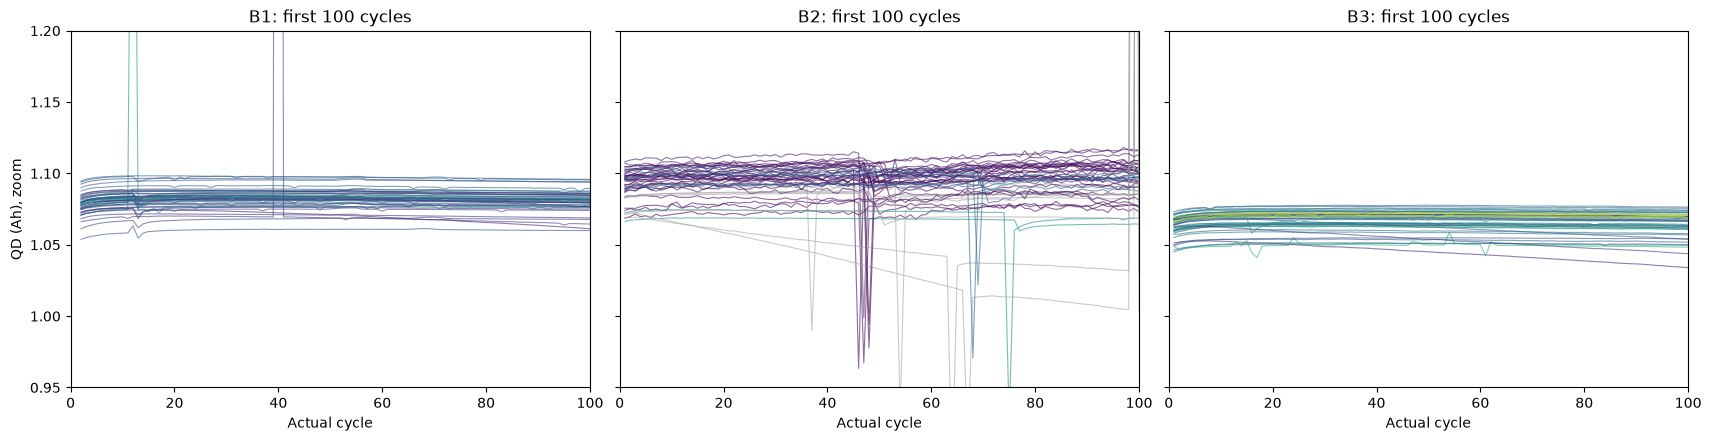

In [10]:
fig, axes = plt.subplots(2,3,figsize=(17,8),sharex='col',constrained_layout=True)
for j,batch in enumerate(BATCH_ORDER):
    for uid,part in eda_raw.loc[eda_raw.batch_id==batch].groupby('cell_uid'):
        life = part.cycle_life.iloc[0]
        color = life_cmap(life_norm(life)) if np.isfinite(life) else '0.65'
        axes[0,j].plot(part.cycle,part.QD,color=color,alpha=.65,lw=.7)
        zoom = eda_clean.loc[eda_clean.cell_uid==uid]
        axes[1,j].plot(zoom.cycle,zoom.QD,color=color,alpha=.65,lw=.7)
    axes[0,j].set(title=f'{batch}: raw QD',ylabel='QD (Ah)')
    axes[1,j].set(title=f'{batch}: capacity zoom',xlabel='Actual cycle',ylabel='QD (Ah)',ylim=(.7,1.3))
    axes[1,j].axhline(.88,color='C3',ls='--',lw=1,label='Nominal 80% reference')
    axes[1,j].legend(fontsize=8)
fig.colorbar(ScalarMappable(norm=life_norm,cmap=life_cmap),ax=axes.ravel().tolist(),label='Cycle life')
plt.show()
fig,axes=plt.subplots(1,3,figsize=(17,4.3),sharey=True,constrained_layout=True)
for ax,batch in zip(axes,BATCH_ORDER):
    for uid,part in eda_clean.loc[(eda_clean.batch_id==batch)&(eda_clean.cycle<=100)].groupby('cell_uid'):
        life = part.cycle_life.iloc[0]
        color = life_cmap(life_norm(life)) if np.isfinite(life) else '0.65'
        ax.plot(part.cycle,part.QD,color=color,alpha=.6,lw=.8)
    ax.set(title=f'{batch}: first 100 cycles',xlabel='Actual cycle',xlim=(0,100),ylim=(.95,1.2))
axes[0].set_ylabel('QD (Ah), zoom')
plt.show()

### 정규화 QD 열화 곡선·초기 기울기·Knee 후보

실제 cycle과 양수 QD만 사용한다. 셀별 **cycle ≤ 10인 양수 QD의 중앙값**을 기준 용량으로 잡고,
전체 곡선에는 관측값 11개 단위의 중앙값 평활화를 적용한다. 초기 기울기는 **실제 cycle ≤ 100**에서
`QD = intercept + slope × cycle`로 계산하며, 회귀 입력은 cycle·QD 두 원변수뿐이다.
초기 구간이 짧거나 기준 용량이 없으면 결과에서 구분한다.

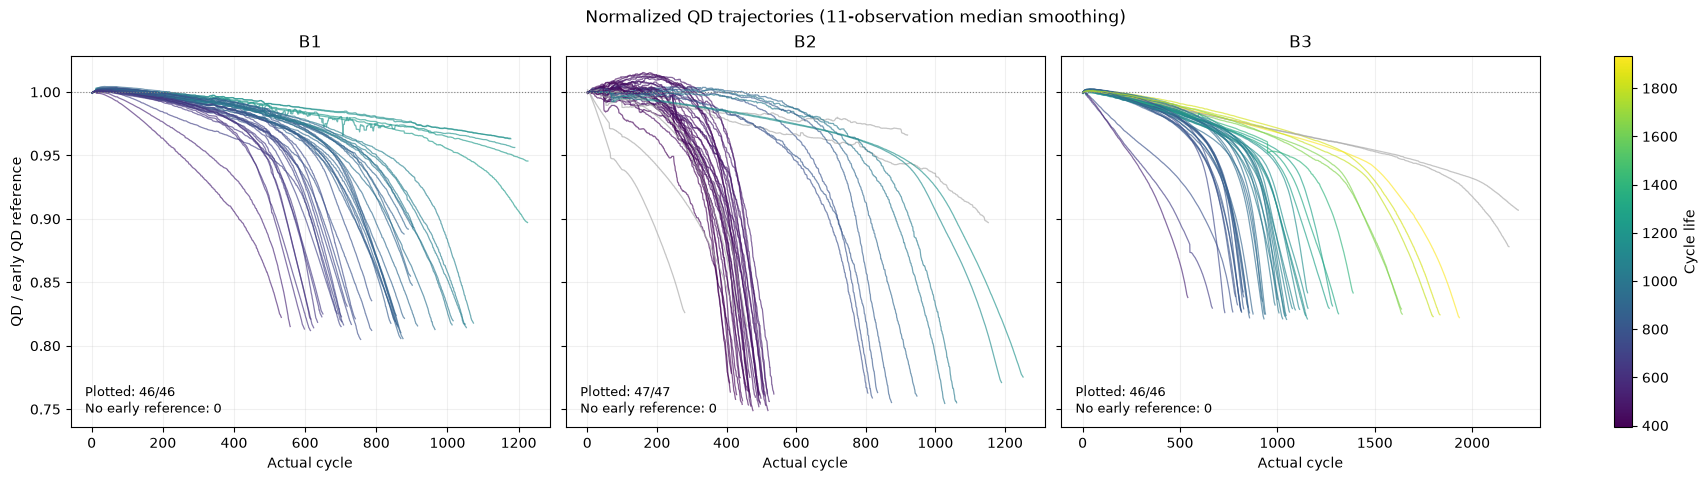

,cells,cells_with_reference,median_reference_QD
batch_id,,,
B1,46,46,1.081129
B2,47,47,1.094920
B3,46,46,1.067768


In [11]:
import matplotlib as mpl

# Repeated measurements at the same actual cycle are represented by their median.
q2_qd = eda_clean[['batch_id', 'cell_id', 'cycle', 'QD']].copy()
q2_qd['cycle'] = pd.to_numeric(q2_qd['cycle'], errors='coerce')
q2_qd['QD'] = pd.to_numeric(q2_qd['QD'], errors='coerce')
q2_qd = q2_qd.loc[
    np.isfinite(q2_qd['cycle']) & np.isfinite(q2_qd['QD'])
    & (q2_qd['cycle'] >= 0) & (q2_qd['QD'] > 0)
].groupby(['batch_id', 'cell_id', 'cycle'], as_index=False)['QD'].median()
q2_meta = cells_all[['batch_id', 'cell_id', 'cycle_life', 'charging_policy']].copy()
q2_qd_groups = {
    key: group.sort_values('cycle').reset_index(drop=True)
    for key, group in q2_qd.groupby(['batch_id', 'cell_id'], sort=False)
}
q2_curves, q2_ref_rows = {}, []
for row in q2_meta.itertuples(index=False):
    key = (row.batch_id, row.cell_id)
    group = q2_qd_groups.get(key)
    initial = group.loc[group['cycle'] <= 10, 'QD'] if group is not None else pd.Series(dtype=float)
    reference = float(initial.median()) if len(initial) else np.nan
    q2_ref_rows.append({
        'batch_id': row.batch_id, 'cell_id': row.cell_id,
        'initial_QD_reference': reference, 'reference_n': len(initial),
        'positive_QD_n': len(group) if group is not None else 0,
    })
    if np.isfinite(reference) and reference > 0:
        curve = group.copy()
        curve['QD_normalized'] = curve['QD'] / reference
        curve['QD_normalized_smooth'] = curve['QD_normalized'].rolling(
            window=11, center=True, min_periods=1
        ).median()
        q2_curves[key] = curve
q2_reference = pd.DataFrame(q2_ref_rows)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.7), sharey=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    plotted = 0
    for row in q2_meta.loc[q2_meta['batch_id'] == batch].itertuples(index=False):
        curve = q2_curves.get((row.batch_id, row.cell_id))
        if curve is None:
            continue
        life = pd.to_numeric(pd.Series([row.cycle_life]), errors='coerce').iloc[0]
        color = life_cmap(life_norm(life)) if np.isfinite(life) and life > 0 else '0.65'
        ax.plot(curve['cycle'], curve['QD_normalized_smooth'], color=color,
                alpha=0.65, linewidth=0.9)
        plotted += 1
    total = int((q2_meta['batch_id'] == batch).sum())
    ax.set(title=batch, xlabel='Actual cycle')
    ax.text(0.03, 0.04, f'Plotted: {plotted}/{total}\nNo early reference: {total - plotted}',
            transform=ax.transAxes, fontsize=9)
    ax.axhline(1, color='0.5', linestyle=':', linewidth=0.8)
    ax.grid(alpha=0.18)
axes[0].set_ylabel('QD / early QD reference')
fig.colorbar(mpl.cm.ScalarMappable(norm=life_norm, cmap=life_cmap),
             ax=list(axes), label='Cycle life')
fig.suptitle('Normalized QD trajectories (11-observation median smoothing)')
plt.show()
display(q2_reference.groupby('batch_id', sort=False).agg(
    cells=('cell_id', 'size'),
    cells_with_reference=('initial_QD_reference', 'count'),
    median_reference_QD=('initial_QD_reference', 'median'),
).reindex(BATCH_ORDER))

,cells,estimated,median_slope_Ah_per_cycle,median_early_cycle_span
batch_id,,,,
B1,46,46,-0.000005,98.0
B2,47,47,0.000032,99.0
B3,46,46,-0.000005,99.0


,batch_id,cell_id,early_QD_n,early_cycle_span,early_QD_slope_Ah_per_cycle,early_QD_r_squared,early_slope_status
0,B1,0,99,98.0,-0.000207,0.016275,estimated
1,B1,1,99,98.0,0.000006,0.017821,estimated
2,B1,2,99,98.0,0.000010,0.083152,estimated
3,B1,3,99,98.0,0.000017,0.201555,estimated
4,B1,4,99,98.0,0.000019,0.248228,estimated
5,B1,5,99,98.0,0.000011,0.094798,estimated
6,B1,6,99,98.0,-0.000005,0.014389,estimated
7,B1,7,99,98.0,-0.000006,0.051197,estimated
8,B1,8,99,98.0,0.000005,0.031922,estimated
9,B1,9,99,98.0,0.000018,0.286310,estimated


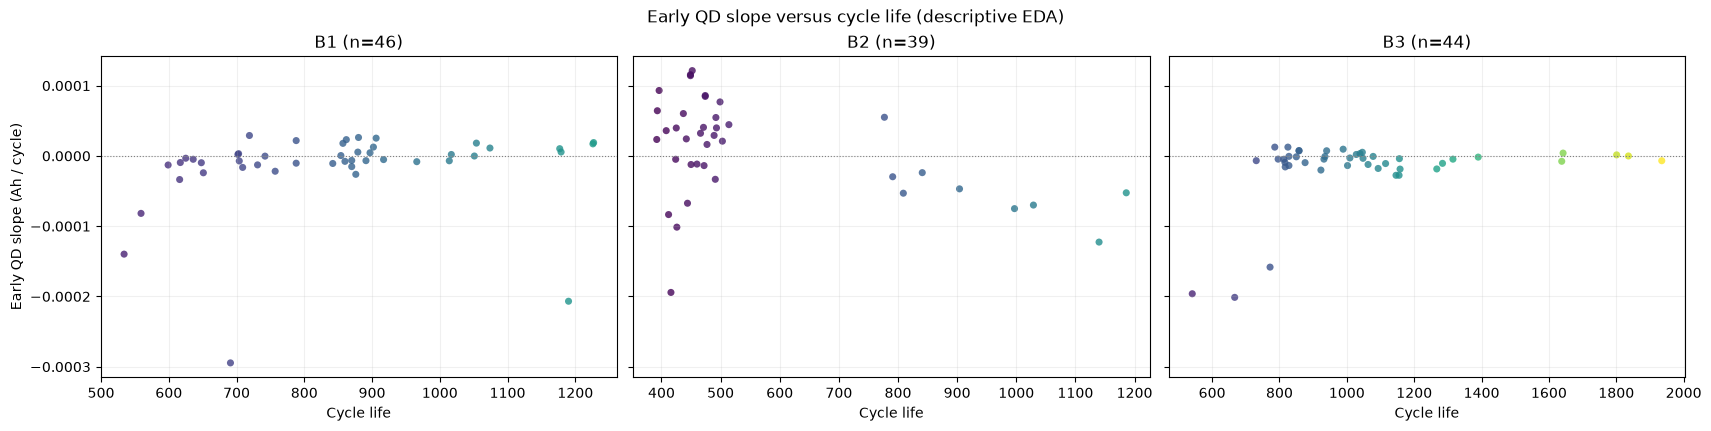

In [12]:
# A minimum of 20 distinct cycles and an actual-cycle span of 50 are required.
# These are support criteria, not a requirement that every cell reaches cycle 100.
q2_early_rows = []
for row in q2_meta.itertuples(index=False):
    group = q2_qd_groups.get((row.batch_id, row.cell_id))
    early = group.loc[group['cycle'] <= 100] if group is not None else pd.DataFrame(columns=['cycle', 'QD'])
    x = early['cycle'].to_numpy(dtype=float)
    y = early['QD'].to_numpy(dtype=float)
    span = float(np.ptp(x)) if len(x) else 0.0
    slope = intercept = r_squared = np.nan
    status = 'insufficient_early_support'
    if len(x) >= 20 and span >= 50:
        xc, yc = x - x.mean(), y - y.mean()
        slope = float(np.dot(xc, yc) / np.dot(xc, xc))
        intercept = float(y.mean() - slope * x.mean())
        residual_sse = float(np.sum((y - (intercept + slope * x)) ** 2))
        total_sse = float(np.sum(yc ** 2))
        r_squared = 1 - residual_sse / total_sse if total_sse > 0 else np.nan
        status = 'estimated'
    q2_early_rows.append({
        'batch_id': row.batch_id, 'cell_id': row.cell_id,
        'early_QD_n': len(x), 'early_cycle_span': span,
        'early_QD_slope_Ah_per_cycle': slope,
        'early_QD_intercept_Ah': intercept, 'early_QD_r_squared': r_squared,
        'early_slope_status': status,
    })
q2_early_slopes = pd.DataFrame(q2_early_rows).merge(q2_meta, on=['batch_id', 'cell_id'], how='left')
display(q2_early_slopes.groupby('batch_id', sort=False).agg(
    cells=('cell_id', 'size'), estimated=('early_QD_slope_Ah_per_cycle', 'count'),
    median_slope_Ah_per_cycle=('early_QD_slope_Ah_per_cycle', 'median'),
    median_early_cycle_span=('early_cycle_span', 'median'),
).reindex(BATCH_ORDER))
display(q2_early_slopes[['batch_id', 'cell_id', 'early_QD_n', 'early_cycle_span',
                        'early_QD_slope_Ah_per_cycle', 'early_QD_r_squared',
                        'early_slope_status']].head(12))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), sharey=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    part = q2_early_slopes.loc[q2_early_slopes['batch_id'] == batch].copy()
    part['cycle_life'] = pd.to_numeric(part['cycle_life'], errors='coerce')
    part = part.loc[np.isfinite(part['cycle_life']) & (part['cycle_life'] > 0)
                    & part['early_QD_slope_Ah_per_cycle'].notna()]
    ax.scatter(part['cycle_life'], part['early_QD_slope_Ah_per_cycle'],
               c=part['cycle_life'], norm=life_norm, cmap=life_cmap,
               s=26, alpha=0.8, edgecolors='none')
    ax.axhline(0, color='0.5', linestyle=':', linewidth=0.8)
    ax.set(title=f'{batch} (n={len(part)})', xlabel='Cycle life')
    ax.grid(alpha=0.18)
axes[0].set_ylabel('Early QD slope (Ah / cycle)')
fig.suptitle('Early QD slope versus cycle life (descriptive EDA)')
plt.show()

**Knee는 사후 EDA 후보이며 예측 모델 입력에 사용하지 않는다.** 전체 평활화 곡선에 연속형 2선분
회귀 `y = a + b·x + c·max(x−k, 0)`를 적합한다. 후보 위치는 관측 cycle 범위의 20–80%에서
약 40개를 탐색한다. 최소 80개 관측·150사이클 범위와 양쪽 20개 관측·40사이클 범위를 요구한다.
탐색용 기준은 직선 대비 SSE 감소율 ≥ 25%, 후반 음의 기울기 크기 ≥ 전반의 2배,
후반의 추가 하락량 ≥ 기준 용량의 2%이다. 이 임계값은 검증된 Knee 정의가 아니다.
미탐지 사유를 남기며, 스파이크·마지막 구간 효과를 실제 Knee로 확정하지 않는다.

In [13]:
Q2_KNEE_SETTINGS = {
    'min_points': 80, 'min_cycle_span': 150,
    'min_side_points': 20, 'min_side_cycle_span': 40,
    'candidate_grid_size': 40, 'max_fit_points': 240,
    'min_relative_sse_gain': 0.25, 'min_slope_acceleration': 2.0,
    'min_extra_late_drop': 0.02,
    # 0.5% of reference capacity over the observed span stabilizes a near-zero denominator.
    'slope_floor_per_observed_span': 0.005,
}

def q2_fit_knee_candidate(curve):
    result = {
        'knee_cycle_candidate': None, 'knee_status': 'insufficient_curve_support',
        'relative_sse_gain': np.nan, 'slope_acceleration': np.nan,
        'early_slope_norm_per_cycle': np.nan, 'late_slope_norm_per_cycle': np.nan,
        'extra_late_drop': np.nan, 'n_curve': len(curve) if curve is not None else 0,
    }
    if curve is None:
        result['knee_status'] = 'no_early_reference'
        return result
    x_all = curve['cycle'].to_numpy(dtype=float)
    y_all = curve['QD_normalized_smooth'].to_numpy(dtype=float)
    span = float(np.ptp(x_all)) if len(x_all) else 0.0
    if len(x_all) < Q2_KNEE_SETTINGS['min_points'] or span < Q2_KNEE_SETTINGS['min_cycle_span']:
        return result
    # Deterministic subsampling keeps the grid search inexpensive for long-lived cells.
    fit_idx = np.unique(np.linspace(0, len(x_all) - 1,
        min(len(x_all), Q2_KNEE_SETTINGS['max_fit_points'])).astype(int))
    x = (x_all[fit_idx] - x_all[0]) / span
    y = y_all[fit_idx]
    baseline = np.column_stack([np.ones(len(x)), x])
    base_coef = np.linalg.lstsq(baseline, y, rcond=None)[0]
    base_sse = float(np.sum((y - baseline @ base_coef) ** 2))
    if base_sse <= np.finfo(float).eps:
        result['knee_status'] = 'no_departure_from_line'
        return result
    best = None
    for k in np.linspace(0.2, 0.8, Q2_KNEE_SETTINGS['candidate_grid_size']):
        cycle_k = float(x_all[0] + k * span)
        left, right = x_all <= cycle_k, x_all > cycle_k
        if min(left.sum(), right.sum()) < Q2_KNEE_SETTINGS['min_side_points']:
            continue
        if min(np.ptp(x_all[left]), np.ptp(x_all[right])) < Q2_KNEE_SETTINGS['min_side_cycle_span']:
            continue
        design = np.column_stack([np.ones(len(x)), x, np.maximum(x - k, 0)])
        coef = np.linalg.lstsq(design, y, rcond=None)[0]
        sse = float(np.sum((y - design @ coef) ** 2))
        if best is None or sse < best['sse']:
            best = {'k': k, 'cycle': cycle_k, 'coef': coef, 'sse': sse}
    if best is None:
        result['knee_status'] = 'insufficient_segment_support'
        return result
    before = float(best['coef'][1])
    after = float(best['coef'][1] + best['coef'][2])
    gain = float(1 - best['sse'] / base_sse)
    acceleration = max(-after, 0.0) / max(abs(before), Q2_KNEE_SETTINGS['slope_floor_per_observed_span'])
    extra_drop = max(before - after, 0.0) * (1 - best['k'])
    result.update({
        'relative_sse_gain': gain, 'slope_acceleration': acceleration,
        'early_slope_norm_per_cycle': before / span,
        'late_slope_norm_per_cycle': after / span, 'extra_late_drop': extra_drop,
    })
    if gain < Q2_KNEE_SETTINGS['min_relative_sse_gain']:
        result['knee_status'] = 'weak_sse_gain'
    elif after >= 0 or after >= before or acceleration < Q2_KNEE_SETTINGS['min_slope_acceleration']:
        result['knee_status'] = 'weak_slope_acceleration'
    elif extra_drop < Q2_KNEE_SETTINGS['min_extra_late_drop']:
        result['knee_status'] = 'small_extra_late_drop'
    else:
        result['knee_status'] = 'candidate_only'
        result['knee_cycle_candidate'] = best['cycle']
        # Store coefficients only for supported candidates and representative plotting.
        result['_fit_coef'] = best['coef']
        result['_fit_k'] = best['k']
    return result

q2_knee_fits, q2_knee_rows = {}, []
for row in q2_meta.itertuples(index=False):
    key = (row.batch_id, row.cell_id)
    fit = q2_fit_knee_candidate(q2_curves.get(key))
    q2_knee_fits[key] = fit
    q2_knee_rows.append({'batch_id': row.batch_id, 'cell_id': row.cell_id,
                        **{k: v for k, v in fit.items() if not k.startswith('_')}})
q2_knee_results = pd.DataFrame(q2_knee_rows).merge(q2_meta, on=['batch_id', 'cell_id'], how='left')
# Stable, compact interface for the subsequent policy/feature EDA cells.
qd_metrics = q2_early_slopes.drop(columns=['cycle_life', 'charging_policy']).merge(
    q2_knee_results, on=['batch_id', 'cell_id'], how='left', validate='one_to_one'
).rename(columns={'early_QD_slope_Ah_per_cycle': 'early_qd_slope',
                  'knee_cycle_candidate': 'knee_candidate'})
display(pd.crosstab(q2_knee_results['batch_id'], q2_knee_results['knee_status'])
        .reindex(BATCH_ORDER, fill_value=0))
display(q2_knee_results[['batch_id', 'cell_id', 'knee_cycle_candidate', 'knee_status',
                        'relative_sse_gain', 'slope_acceleration', 'extra_late_drop']]
        .sort_values(['batch_id', 'cell_id']).head(15))

knee_status,candidate_only,insufficient_curve_support,small_extra_late_drop,weak_slope_acceleration,weak_sse_gain
batch_id,,,,,
B1,42,0,2,1,1
B2,43,2,0,2,0
B3,44,0,1,1,0


,batch_id,cell_id,knee_cycle_candidate,knee_status,relative_sse_gain,slope_acceleration,extra_late_drop
0,B1,0,NaN,weak_sse_gain,0.167334,1.637473,0.014912
1,B1,1,NaN,weak_slope_acceleration,0.864245,1.990404,0.015728
2,B1,2,NaN,small_extra_late_drop,0.835109,2.126087,0.016474
3,B1,3,961.584615,candidate_only,0.928740,5.715025,0.051377
4,B1,4,NaN,small_extra_late_drop,0.821008,2.194788,0.014648
5,B1,5,858.800000,candidate_only,0.938162,9.631323,0.110917
6,B1,6,508.400000,candidate_only,0.957813,10.350779,0.116877
7,B1,7,642.246154,candidate_only,0.961839,9.352593,0.131446
8,B1,8,675.846154,candidate_only,0.952055,7.357780,0.068249
9,B1,9,794.292308,candidate_only,0.956525,9.116943,0.120955


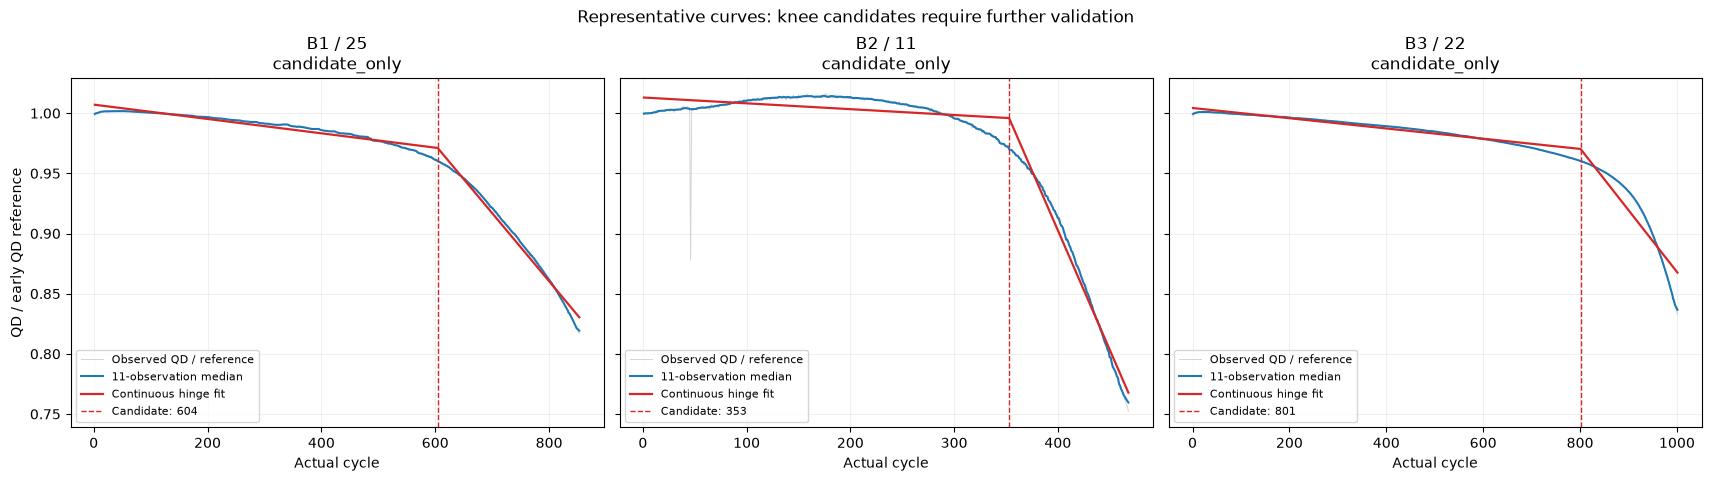

,batch_id,cell_id,knee_status,knee_cycle_candidate
0,B1,25,candidate_only,604.246154
1,B2,11,candidate_only,353.046154
2,B3,22,candidate_only,801.000000


In [14]:
# One representative per batch: candidate nearest the median candidate cycle;
# if none is detected, choose the longest supported observed trajectory.
q2_representatives = []
fig, axes = plt.subplots(1, 3, figsize=(17, 4.7), sharey=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    part = q2_knee_results.loc[q2_knee_results['batch_id'] == batch].copy()
    detected = part.loc[part['knee_status'] == 'candidate_only']
    if len(detected):
        selection = (detected['knee_cycle_candidate'] - detected['knee_cycle_candidate'].median()).abs().idxmin()
    else:
        available = part.loc[part.apply(lambda r: (r['batch_id'], r['cell_id']) in q2_curves, axis=1)]
        selection = available['n_curve'].idxmax() if len(available) else None
    if selection is None:
        ax.set(title=batch, xlabel='Actual cycle')
        ax.text(0.5, 0.5, 'No supported normalized curve', ha='center', va='center', transform=ax.transAxes)
        continue
    selected = part.loc[selection]
    key = (batch, selected['cell_id'])
    curve, fit = q2_curves[key], q2_knee_fits[key]
    ax.plot(curve['cycle'], curve['QD_normalized'], color='0.72', linewidth=0.7,
            alpha=0.6, label='Observed QD / reference')
    ax.plot(curve['cycle'], curve['QD_normalized_smooth'], color='C0', linewidth=1.5,
            label='11-observation median')
    if fit['knee_status'] == 'candidate_only':
        span = float(np.ptp(curve['cycle'].to_numpy(dtype=float)))
        xn = (curve['cycle'].to_numpy(dtype=float) - curve['cycle'].iloc[0]) / span
        coef = fit['_fit_coef']
        predicted = coef[0] + coef[1] * xn + coef[2] * np.maximum(xn - fit['_fit_k'], 0)
        ax.plot(curve['cycle'], predicted, color='C3', linewidth=1.6, label='Continuous hinge fit')
        ax.axvline(fit['knee_cycle_candidate'], color='C3', linestyle='--', linewidth=1,
                   label=f"Candidate: {fit['knee_cycle_candidate']:.0f}")
    ax.set(title=f"{batch} / {selected['cell_id']}\n{fit['knee_status']}", xlabel='Actual cycle')
    ax.grid(alpha=0.18)
    ax.legend(fontsize=8, loc='best')
    q2_representatives.append({'batch_id': batch, 'cell_id': selected['cell_id'],
                               'knee_status': fit['knee_status'],
                               'knee_cycle_candidate': fit['knee_cycle_candidate']})
axes[0].set_ylabel('QD / early QD reference')
fig.suptitle('Representative curves: knee candidates require further validation')
plt.show()
display(pd.DataFrame(q2_representatives))

### Knee 후보의 설정 민감도

평활화 폭(5/11/21개 관측)과 후보 격자(20/40/80개)를 바꿔 같은 셀이 계속 후보로 잡히는지 확인한다.
9설정 모두 후보이고 위치 범위가 전체 관측 사이클 범위의 10% 이하인 경우를 **설정에 비교적 안정적인 후보**로 표시한다.
이 10% 기준도 탐색 규칙이며 물리적 Knee의 확정 기준이 아니다. 미탐지는 Knee가 없다는 증명이 아니다.

In [15]:
from itertools import product
q2_original_settings = Q2_KNEE_SETTINGS.copy()
knee_sensitivity_rows = []
try:
    for window,grid in product([5,11,21],[20,40,80]):
        Q2_KNEE_SETTINGS['candidate_grid_size'] = grid
        for (batch,cid),curve in q2_curves.items():
            variant = curve.copy()
            variant['QD_normalized_smooth'] = variant.QD_normalized.rolling(window,center=True,min_periods=1).median()
            fit = q2_fit_knee_candidate(variant)
            knee_sensitivity_rows.append({'batch_id':batch,'cell_id':cid,'window':window,'grid':grid,
                'knee_status':fit['knee_status'],'knee_cycle_candidate':fit['knee_cycle_candidate']})
finally:
    Q2_KNEE_SETTINGS.clear(); Q2_KNEE_SETTINGS.update(q2_original_settings)
knee_sensitivity = pd.DataFrame(knee_sensitivity_rows)
knee_stability = knee_sensitivity.groupby(['batch_id','cell_id']).agg(
    settings_tested=('grid','size'), settings_detected=('knee_cycle_candidate','count'),
    candidate_min=('knee_cycle_candidate','min'),candidate_max=('knee_cycle_candidate','max'))
observed_span = eda_clean.groupby(['batch_id','cell_id']).cycle.agg(lambda x:float(x.max()-x.min()))
knee_stability['candidate_span_fraction'] = (knee_stability.candidate_max-knee_stability.candidate_min)/observed_span
knee_stability['stable_candidate'] = knee_stability.settings_detected.eq(9)&knee_stability.candidate_span_fraction.le(.10)
display(knee_stability.groupby(level='batch_id').agg(
    cells=('settings_tested','size'),all_settings_detected=('settings_detected',lambda x:int((x==9).sum())),
    stable_candidates=('stable_candidate','sum'),median_position_span=('candidate_span_fraction','median')))
display(knee_stability.sort_values('candidate_span_fraction',ascending=False).head(12))
print('Knee/후기 기울기는 사후 EDA이며 early feature 표에 넣지 않는다.')

,cells,all_settings_detected,stable_candidates,median_position_span
batch_id,,,,
B1,46,42,42,0.010593
B2,47,43,43,0.014575
B3,46,44,44,0.000600


settings_tested  settings_detected  candidate_min  candidate_max  candidate_span_fraction  stable_candidate
batch_id cell_id                                                                                                             
B2       21                     9                  9     300.736842     314.157895                 0.031579              True
         28                     9                  9     321.894737     336.263158                 0.031579              True
B1       21                     9                  9     429.242105     446.800000                 0.031579              True
B3       11                     9                  9     627.263158     653.000000                 0.031579              True
B2       17                     9                  9     339.235443     348.694737                 0.019187              True
B1       11                     9                  9     580.421053     594.227848                 0.017588              True
B2       8                      9                  9     698.052632     714.691139                 0.017588              True
B1       39                     9                  9     460.315789     471.255696                 0.017588              True
B2       45                     9                  9     757.000000     775.045570                 0.017588              True
         19                     9                  9     303.105263     310.076923                 0.017004              True
         11                     9                  9     345.105263     353.046154                 0.017004              True
B1       26                     9                  9     640.842105     655.584615                 0.017004              True

Knee/후기 기울기는 사후 EDA이며 early feature 표에 넣지 않는다.


## Q3. 초기 ΔQ(V) 곡선은 수명 집단을 구분하는가?

`ΔQ(V) = Qdlin(actual cycle 100) − Qdlin(actual cycle 10)`으로 정의한다.
Summary의 **실제 cycle 값**으로 두 관측 위치를 찾고, 각 Qdlin과 셀의 Vdlin이 모두 유한한
1000점·단조 전압 그리드인지 확인한다. 실제 cycle 누락·중복, 길이 불일치 등은 제외 사유를 남긴다.
수명이 없는 셀도 ΔQ 원곡선에는 회색으로 표시하며 수명 비교·상관계수에서만 제외한다.

dq_status,ok
batch_id,
B1,46
B2,47
B3,46


,cells,delta_q_var_n,log_variance_n,median_delta_q_var,median_delta_q_min
batch_id,,,,,
B1,46,46,46,0.000141,-0.036350
B2,47,47,47,0.000320,-0.053254
B3,46,46,46,0.000063,-0.024483


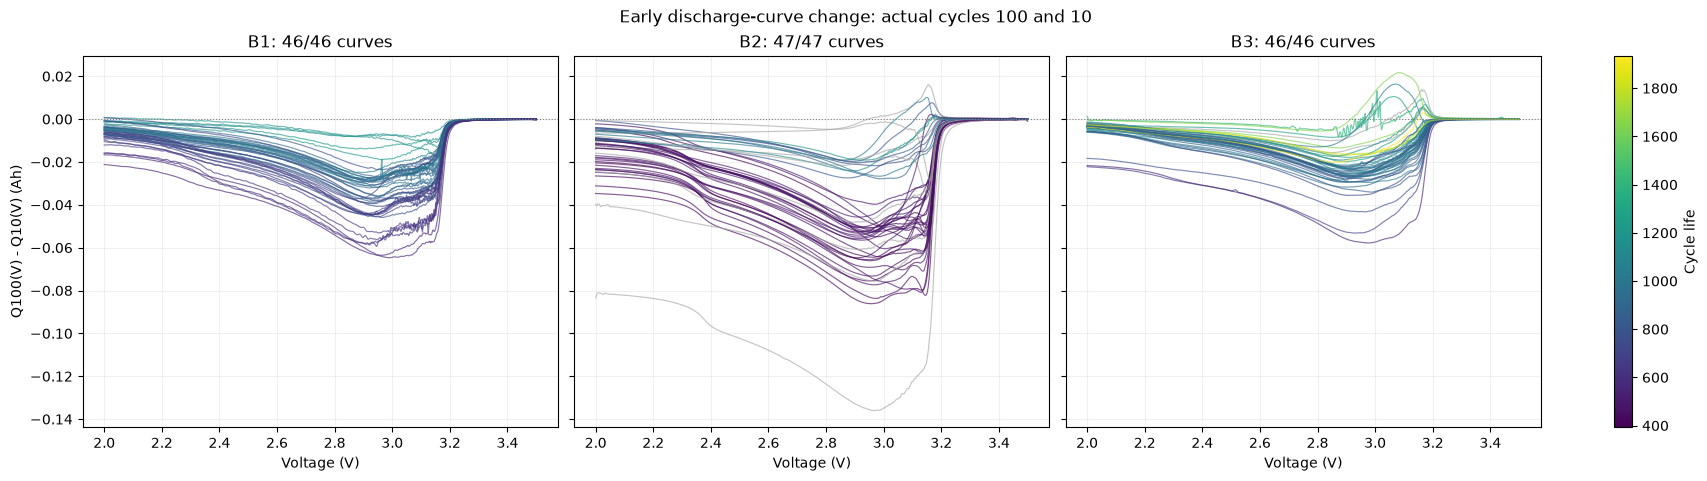

In [16]:
import matplotlib as mpl

_q34_meta = cells_all.copy()
if 'life' not in _q34_meta:
    _q34_meta['life'] = _q34_meta['cycle_life']
if 'charging_policy' not in _q34_meta:
    _q34_meta['charging_policy'] = _q34_meta['policy']
_q34_meta['life'] = pd.to_numeric(_q34_meta['life'], errors='coerce')
_q34_meta.loc[~np.isfinite(_q34_meta['life']) | (_q34_meta['life'] <= 0), 'life'] = np.nan
_q34_meta = _q34_meta[['batch_id', 'cell_id', 'cell_uid', 'life', 'charging_policy']].copy()

def _q34_vector(f, reference_dataset, position):
    refs = np.asarray(reference_dataset).reshape(-1)
    if position < 0 or position >= len(refs):
        raise IndexError('reference_position_out_of_bounds')
    return np.asarray(f[refs[position]], dtype=float).reshape(-1)

def _q34_actual_index(actual_cycles, cycle):
    found = np.flatnonzero(np.isclose(actual_cycles, cycle, rtol=0, atol=1e-8))
    if len(found) != 1:
        raise ValueError(f'actual_cycle_{cycle}_' + ('missing' if len(found) == 0 else 'duplicated'))
    return int(found[0])

dq_curves, voltage_grids, _q3_rows = {}, {}, []
for batch in BATCH_ORDER:
    with h5py.File(BATCH_FILES[batch], 'r') as f:
        b = f['batch']
        for cell in _q34_meta.loc[_q34_meta['batch_id'] == batch].itertuples(index=False):
            record = {'cell_uid': cell.cell_uid, 'batch_id': batch, 'cell_id': cell.cell_id,
                      'life': cell.life, 'delta_q_var': np.nan, 'log10_delta_q_var': np.nan,
                      'delta_q_min': np.nan, 'delta_q_mean': np.nan,
                      'q10_n': 0, 'q100_n': 0, 'voltage_n': 0, 'dq_status': 'not_read'}
            try:
                ci = int(cell.cell_id)
                summaries = np.asarray(b['summary']).reshape(-1)
                cycles_refs = np.asarray(b['cycles']).reshape(-1)
                summary = f[summaries[ci]]
                cycles = f[cycles_refs[ci]]
                actual = np.asarray(summary['cycle'], dtype=float).reshape(-1)
                if len(actual) != int(np.prod(cycles['Qdlin'].shape)):
                    raise ValueError('summary_and_Qdlin_cycle_count_mismatch')
                p10, p100 = _q34_actual_index(actual, 10), _q34_actual_index(actual, 100)
                q10 = _q34_vector(f, cycles['Qdlin'], p10)
                q100 = _q34_vector(f, cycles['Qdlin'], p100)
                voltage = _q34_vector(f, b['Vdlin'], ci)
                record.update(q10_n=len(q10), q100_n=len(q100), voltage_n=len(voltage))
                if len(q10) != 1000 or len(q100) != 1000 or len(voltage) != 1000:
                    raise ValueError('Qdlin_or_voltage_length_not_1000')
                if not (np.isfinite(q10).all() and np.isfinite(q100).all() and np.isfinite(voltage).all()):
                    raise ValueError('nonfinite_Qdlin_or_voltage')
                if not ((np.diff(voltage) > 0).all() or (np.diff(voltage) < 0).all()):
                    raise ValueError('voltage_grid_not_strictly_monotonic')
                if np.ptp(q10) <= 0 or np.ptp(q100) <= 0:
                    raise ValueError('constant_or_placeholder_Qdlin')
                delta = q100 - q10
                variance = float(np.var(delta, ddof=0))
                record.update(delta_q_var=variance, delta_q_min=float(delta.min()),
                              delta_q_mean=float(delta.mean()),
                              log10_delta_q_var=np.log10(variance) if variance > 0 else np.nan,
                              dq_status='ok' if variance > 0 else 'zero_variance_log_undefined')
                dq_curves[cell.cell_uid], voltage_grids[cell.cell_uid] = delta, voltage
            except (KeyError, IndexError, ValueError, TypeError, OSError) as exc:
                record['dq_status'] = str(exc)
            _q3_rows.append(record)
dq_features = pd.DataFrame(_q3_rows).set_index('cell_uid')
dq_features['cycle_life'] = dq_features['life']
display(pd.crosstab(dq_features['batch_id'], dq_features['dq_status']).reindex(BATCH_ORDER, fill_value=0))
display(dq_features.groupby('batch_id').agg(
    cells=('cell_id', 'size'), delta_q_var_n=('delta_q_var', 'count'),
    log_variance_n=('log10_delta_q_var', 'count'),
    median_delta_q_var=('delta_q_var', 'median'), median_delta_q_min=('delta_q_min', 'median')
).reindex(BATCH_ORDER))

_q3_lives = _q34_meta['life'].dropna()
_q3_vmin = float(_q3_lives.min()) if len(_q3_lives) else 0.0
_q3_vmax = float(_q3_lives.max()) if len(_q3_lives) else 1.0
_q3_norm = mpl.colors.Normalize(_q3_vmin, _q3_vmax if _q3_vmax > _q3_vmin else _q3_vmin + 1)
_q3_cmap = plt.get_cmap('viridis')
fig, axes = plt.subplots(1, 3, figsize=(17, 4.7), sharey=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    part = dq_features.loc[dq_features['batch_id'] == batch]
    n_curve = 0
    for uid, row in part.iterrows():
        if uid not in dq_curves:
            continue
        color = _q3_cmap(_q3_norm(row['life'])) if np.isfinite(row['life']) else '0.65'
        ax.plot(voltage_grids[uid], dq_curves[uid], color=color, alpha=0.65, linewidth=0.85)
        n_curve += 1
    ax.set(title=f'{batch}: {n_curve}/{len(part)} curves', xlabel='Voltage (V)')
    ax.axhline(0, color='0.5', linestyle=':', linewidth=0.8)
    ax.grid(alpha=0.18)
axes[0].set_ylabel('Q100(V) - Q10(V) (Ah)')
fig.colorbar(mpl.cm.ScalarMappable(norm=_q3_norm, cmap=_q3_cmap), ax=list(axes), label='Cycle life')
fig.suptitle('Early discharge-curve change: actual cycles 100 and 10')
plt.show()

장수명은 `life > 1000`, 단수명은 `life < 500`으로 고정해 배치별로 비교한다.
음영은 동일 전압 위치에서의 **셀 간 표본 SD(ddof=1)**이며 신뢰구간이 아니다.
n=0이면 곡선을 그리지 않고, n=1이면 평균만 표시한다. 중간 수명은 이 두 집단 비교에서 제외된다.

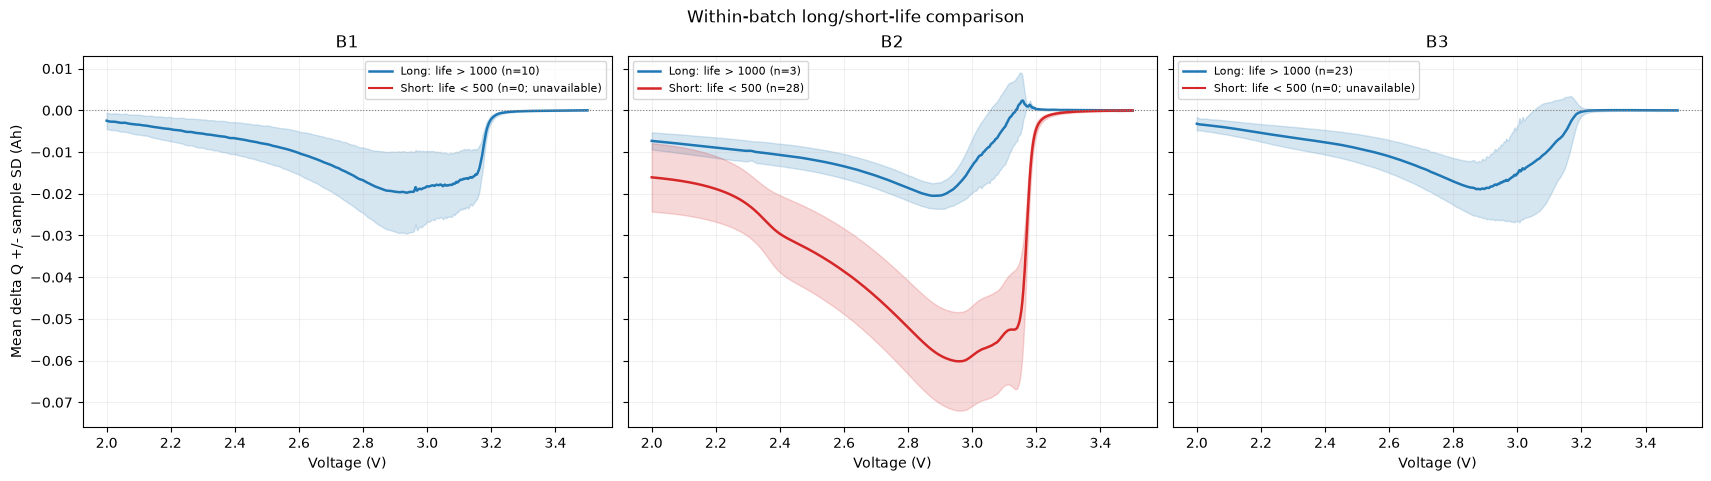

,batch_id,life_group,eligible_life_cells,curve_n,unavailable_curve_n,grid_mismatch_n,sample_sd_available
0,B1,Long: life > 1000,10,10,0,0,True
1,B1,Short: life < 500,0,0,0,0,False
2,B2,Long: life > 1000,3,3,0,0,True
3,B2,Short: life < 500,28,28,0,0,True
4,B3,Long: life > 1000,23,23,0,0,True
5,B3,Short: life < 500,0,0,0,0,False


In [17]:
_q3_group_rows = []
fig, axes = plt.subplots(1, 3, figsize=(17, 4.7), sharey=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    part = dq_features.loc[dq_features['batch_id'] == batch]
    groups = [('Long: life > 1000', part.index[part['life'] > 1000], 'C0'),
              ('Short: life < 500', part.index[part['life'] < 500], 'C3')]
    for label, uids, color in groups:
        valid = [uid for uid in uids if uid in dq_curves]
        base_grid = voltage_grids[valid[0]] if valid else None
        matched = [uid for uid in valid if np.allclose(voltage_grids[uid], base_grid, rtol=0, atol=1e-8)]
        n = len(matched)
        _q3_group_rows.append({'batch_id': batch, 'life_group': label,
            'eligible_life_cells': len(uids), 'curve_n': n,
            'unavailable_curve_n': len(uids) - len(valid), 'grid_mismatch_n': len(valid) - n,
            'sample_sd_available': n >= 2})
        if n:
            stack = np.stack([dq_curves[uid] for uid in matched])
            mean = stack.mean(axis=0)
            ax.plot(base_grid, mean, color=color, linewidth=1.8, label=f'{label} (n={n})')
            if n >= 2:
                sd = stack.std(axis=0, ddof=1)
                ax.fill_between(base_grid, mean - sd, mean + sd, color=color, alpha=0.18)
        else:
            ax.plot([], [], color=color, label=f'{label} (n=0; unavailable)')
    ax.set(title=batch, xlabel='Voltage (V)')
    ax.axhline(0, color='0.5', linestyle=':', linewidth=0.8)
    ax.grid(alpha=0.18)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Mean delta Q +/- sample SD (Ah)')
fig.suptitle('Within-batch long/short-life comparison')
plt.show()
dq_group_counts = pd.DataFrame(_q3_group_rows)
display(dq_group_counts)

ΔQ의 분산은 전압 위치별 변화가 얼마나 불균일한지, 최솟값은 가장 큰 국소 감소를 요약한다.
`log10(var)`는 양수 분산의 크기 차이를 압축한다. 분산은 1000점 전압 벡터의 요약값이므로 ddof=0이다.
이 피처의 초기 방전곡선 기반 근거는 [Severson·Attia 등, 2019](https://petermattia.com/papers/Severson,%20Attia%20et%20al.%20-%202019%20-%20Data-driven%20prediction%20of%20battery%20cycle%20life%20before%20capacity%20degradation.pdf)의 Fig. 2·Methods이다.
여기서는 로컬 3배치의 연관성을 확인하며 논문 성능을 재현했다고 해석하지 않는다.

,batch_id,feature,n_pairs,excluded_n,spearman_rho,status
0,B1,delta_q_var,46,0,-0.871161,ok
1,B1,log10_delta_q_var,46,0,-0.871161,ok
2,B1,delta_q_min,46,0,0.850006,ok
3,B2,delta_q_var,39,8,-0.708979,ok
4,B2,log10_delta_q_var,39,8,-0.708979,ok
5,B2,delta_q_min,39,8,0.660897,ok
6,B3,delta_q_var,44,2,-0.797237,ok
7,B3,log10_delta_q_var,44,2,-0.797237,ok
8,B3,delta_q_min,44,2,0.776024,ok


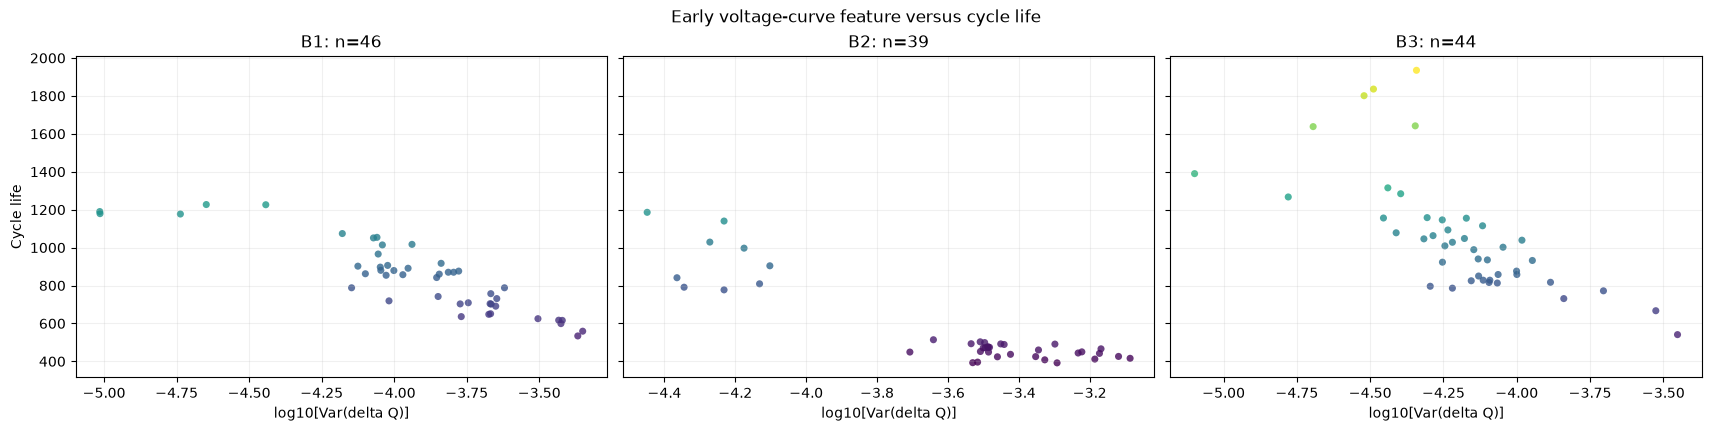

In [18]:
_q3_assoc_rows = []
for batch in BATCH_ORDER:
    part = dq_features.loc[dq_features['batch_id'] == batch]
    for feature in ['delta_q_var', 'log10_delta_q_var', 'delta_q_min']:
        pairs = part[[feature, 'life']].replace([np.inf, -np.inf], np.nan).dropna()
        reason = 'ok'
        if len(pairs) < 3:
            reason = 'fewer_than_3_pairs'
        elif pairs[feature].nunique() < 2 or pairs['life'].nunique() < 2:
            reason = 'constant_variable'
        _q3_assoc_rows.append({'batch_id': batch, 'feature': feature,
            'n_pairs': len(pairs), 'excluded_n': len(part) - len(pairs),
            'spearman_rho': pairs[feature].corr(pairs['life'], method='spearman') if reason == 'ok' else np.nan,
            'status': reason})
dq_associations = pd.DataFrame(_q3_assoc_rows)
display(dq_associations)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), sharey=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    part = dq_features.loc[dq_features['batch_id'] == batch]
    pairs = part[['log10_delta_q_var', 'life']].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(pairs['log10_delta_q_var'], pairs['life'], c=pairs['life'],
               norm=_q3_norm, cmap=_q3_cmap, s=26, alpha=0.8, edgecolors='none')
    ax.set(title=f'{batch}: n={len(pairs)}', xlabel='log10[Var(delta Q)]')
    ax.grid(alpha=0.18)
axes[0].set_ylabel('Cycle life')
fig.suptitle('Early voltage-curve feature versus cycle life')
plt.show()

## Q4. 충전 정책·실제 전류 패턴과 수명/초기 열화는 어떻게 연결되는가?

`C1C(SOC%)-C2C`를 C1·전환 SOC·C2로 분해한다. 논문 프로토콜에서는 C1이 0→전환 SOC,
C2가 전환 SOC→80%이고, **80→100%는 공통 1C CC-CV**이다. C2가 100%까지 지속된다는 뜻이 아니다.
`newstructure` 등 접미사는 보존하며 정규식만으로 그 의미를 확정하지 않는다.
로컬 B2 파일은 논문 배치와 날짜가 다르므로 같은 실험조건이라고 가정하지 않는다.

[논문 Methods](https://petermattia.com/papers/Severson,%20Attia%20et%20al.%20-%202019%20-%20Data-driven%20prediction%20of%20battery%20cycle%20life%20before%20capacity%20degradation.pdf)는 명목 용량 **1.1 Ah와 1C=1.1 A**를 정의한다.
이는 데이터에서 추정한 용량이 아니다. 로컬 `I`는 이미 정규화된 값일 가능성이 있어 단위를 확정하지 않고
**native I**로 요약한다. `Qc / ∫I_native dt/60` 진단값이 약 1.1이면 I가 C-rate일 가능성을 뒷받침하나
단위를 확정하지 않는다. 따라서 native I를 다시 1.1로 나누지 않는다.

policy_parse_status,parsed,parsed_with_suffix,unparsed
batch_id,,,
B1,46,0,0
B2,30,13,4
B3,0,46,0


C1                 SOC_switch_pct                         C2                
              mean       std count           mean        std count      mean       std count
batch_id                                                                                    
B1        5.878261  1.202574    46      51.521739  19.461345    46  3.582609  0.583973    46
B2        4.962791  0.660275    43      50.720930  22.630916    43  4.547674  0.665203    43
B3        5.219565  0.535255    46      48.347826  22.218328    46  4.406522  0.563482    46

,batch_id,charging_policy,cell_n,valid_life_n,life_mean,life_sample_sd,C1,SOC_switch_pct,C2
0,B1,3.6C(80%)-3.6C,3,3,1182.000000,7.000000,3.60,80.0,3.60
1,B1,4.4C(80%)-4.4C,1,1,1074.000000,NaN,4.40,80.0,4.40
2,B1,4.8C(80%)-4.8C,2,2,753.000000,165.462987,4.80,80.0,4.80
3,B1,4C(80%)-4C,2,2,1226.500000,0.707107,4.00,80.0,4.00
4,B1,5.4C(40%)-3.6C,2,2,966.500000,123.743687,5.40,40.0,3.60
5,B1,5.4C(50%)-3.6C,2,2,899.500000,3.535534,5.40,50.0,3.60
6,B1,5.4C(50%)-3C,2,2,847.000000,83.438600,5.40,50.0,3.00
7,B1,5.4C(60%)-3.6C,2,2,859.500000,3.535534,5.40,60.0,3.60
8,B1,5.4C(60%)-3C,2,2,799.500000,113.844192,5.40,60.0,3.00
9,B1,5.4C(70%)-3C,2,2,739.500000,68.589358,5.40,70.0,3.00


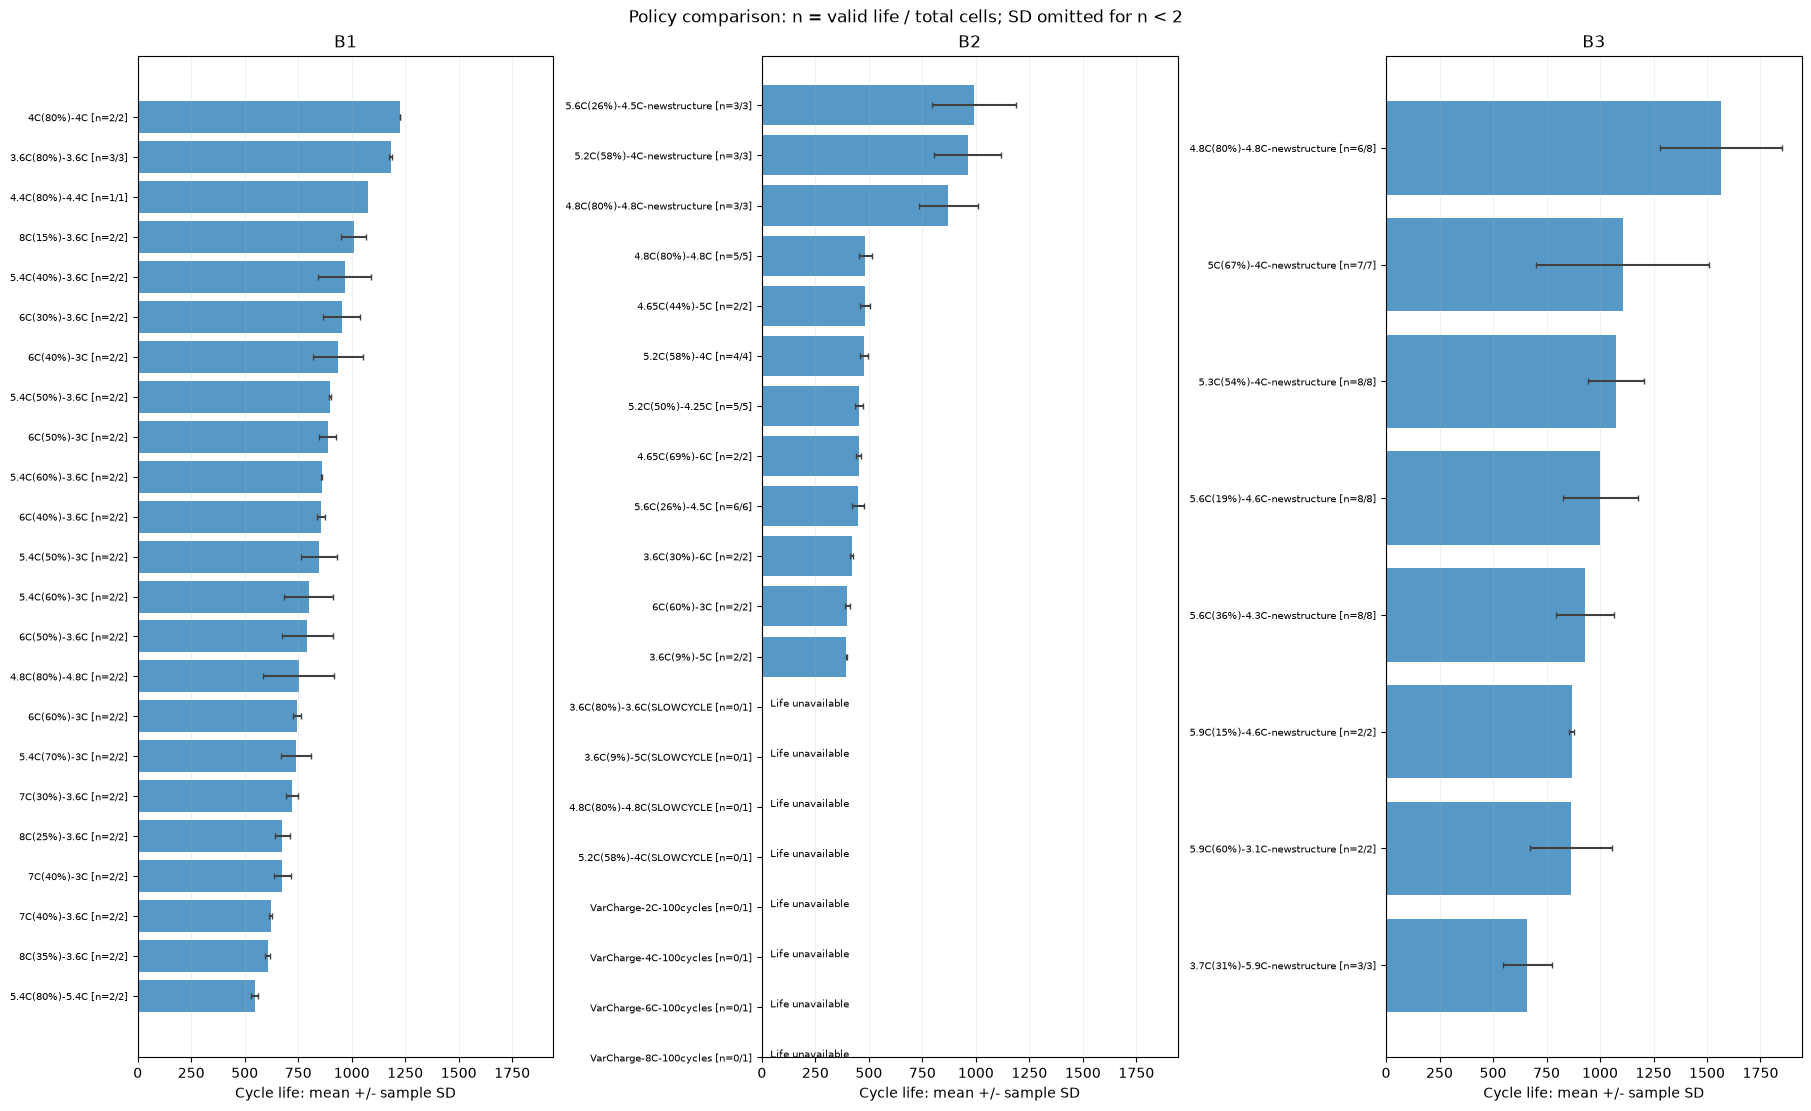

In [19]:
import re
Q4_NOMINAL_CAPACITY_AH = 1.1  # Paper specification, not an estimate from these data.
_q4_policy_pattern = re.compile(
    r'^\s*(?P<C1>\d+(?:\.\d+)?)\s*C\s*\(\s*(?P<SOC>\d+(?:\.\d+)?)\s*%\s*\)\s*-\s*'
    r'(?P<C2>\d+(?:\.\d+)?)\s*C(?P<suffix>.*)$', re.IGNORECASE
)
_q4_policy_rows = []
for cell in _q34_meta.itertuples(index=False):
    text = '' if pd.isna(cell.charging_policy) else str(cell.charging_policy)
    match = _q4_policy_pattern.fullmatch(text)
    record = {'cell_uid': cell.cell_uid, 'batch_id': cell.batch_id, 'cell_id': cell.cell_id,
              'life': cell.life, 'charging_policy': text, 'C1': np.nan, 'SOC_switch_pct': np.nan,
              'C2': np.nan, 'policy_suffix': '', 'policy_parse_status': 'unparsed'}
    if match:
        record.update(C1=float(match['C1']), SOC_switch_pct=float(match['SOC']),
                      C2=float(match['C2']), policy_suffix=match['suffix'].strip())
        if 0 < record['SOC_switch_pct'] <= 80 and record['C1'] > 0 and record['C2'] > 0:
            record['policy_parse_status'] = 'parsed_with_suffix' if record['policy_suffix'] else 'parsed'
        else:
            record['policy_parse_status'] = 'out_of_protocol_range'
            record.update(C1=np.nan, SOC_switch_pct=np.nan, C2=np.nan)
    _q4_policy_rows.append(record)
policy_features = pd.DataFrame(_q4_policy_rows).set_index('cell_uid')
display(pd.crosstab(policy_features['batch_id'], policy_features['policy_parse_status'])
        .reindex(BATCH_ORDER, fill_value=0))
display(policy_features.groupby('batch_id')[['C1', 'SOC_switch_pct', 'C2']]
        .agg(['mean', 'std', 'count']).reindex(BATCH_ORDER))
policy_life_stats = policy_features.groupby(['batch_id', 'charging_policy'], dropna=False).agg(
    cell_n=('cell_id', 'size'), valid_life_n=('life', 'count'),
    life_mean=('life', 'mean'), life_sample_sd=('life', 'std'),
    C1=('C1', 'first'), SOC_switch_pct=('SOC_switch_pct', 'first'), C2=('C2', 'first')
).reset_index()
display(policy_life_stats)
fig, axes = plt.subplots(1, 3, figsize=(18, 11), sharex=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    part = policy_life_stats.loc[policy_life_stats['batch_id'] == batch].sort_values(
        'life_mean', ascending=False, na_position='last').reset_index(drop=True)
    positions = np.arange(len(part))
    finite_mean = np.isfinite(part['life_mean'])
    ax.barh(positions[finite_mean], part.loc[finite_mean, 'life_mean'], color='C0', alpha=0.75)
    with_sd = finite_mean & part['life_sample_sd'].notna()
    ax.errorbar(part.loc[with_sd, 'life_mean'], positions[with_sd],
                xerr=part.loc[with_sd, 'life_sample_sd'], fmt='none', ecolor='0.25', capsize=2)
    labels = [f"{r.charging_policy} [n={r.valid_life_n}/{r.cell_n}]" for r in part.itertuples(index=False)]
    ax.set_yticks(positions, labels, fontsize=7)
    for position in positions[~finite_mean]:
        ax.text(0.02, position, 'Life unavailable', transform=ax.get_yaxis_transform(), fontsize=7)
    ax.invert_yaxis()
    ax.set(title=batch, xlabel='Cycle life: mean +/- sample SD')
    ax.grid(axis='x', alpha=0.18)
fig.suptitle('Policy comparison: n = valid life / total cells; SD omitted for n < 2')
plt.show()

실제 Summary cycle 10·50·100의 `I,t,Qc`를 읽는다. 충전 시간 구간은 **양 끝 I>0**, 유한 I/t,
**dt>0**인 인접 관측 간격으로 정의한다. 양 끝 전류의 평균을 dt로 가중해 평균·표준편차를 계산하고
피크는 해당 구간의 전류 최댓값으로 잡는다. 전체 양의 전류 구간을 포함하므로 CC·CV·양의 IR 펄스가
섞일 수 있고, 정책의 빠른 첫 단계만을 측정한 지표가 아니다. t는 분 단위로 해석해 적분 진단을 계산한다.
Qc가 유효하면 충전 구간의 음이 아닌 용량 증가량을 합한다. **I>0·dt>0 충전 구간에서 Qc 감소가
1e−6 Ah를 초과하는 관측이 하나라도 있으면 해당 cycle의 Qc 용량·적분비만 통계에서 제외**한다.
허용 범위의 작은 음의 증가량은 0으로 처리하며, 감소 개수와 감소량 합계 및 누락 사유를 남긴다.
Qc 이상이나 누락이 있어도 유효한 전류 통계는 보존한다.
셀 피처는 사용 가능한 세 cycle의 평균(피크는 최댓값)이고, 관측 cycle 수와 누락 사유를 함께 남긴다.

In [20]:
_q4_cycle_rows, current_profiles = [], {}
Q4_SAMPLE_CYCLES = [10, 50, 100]
Q4_QC_DECREASE_TOL_AH = 1e-6

def _q4_current_cycle(f, cycles, actual, cycle):
    result = {'actual_cycle': cycle, 'charge_I_mean': np.nan, 'charge_I_peak': np.nan,
        'charge_I_std': np.nan, 'charge_duration_min': np.nan, 'charge_Qc_increment': np.nan,
        'native_I_time_integral': np.nan, 'Qc_to_native_integral_ratio': np.nan,
        'Qc_negative_step_n': np.nan, 'Qc_decrease_sum_Ah': np.nan,
        'charge_intervals_n': 0, 'current_status': 'not_read', 'Qc_status': 'not_read'}
    profile = None
    try:
        p = _q34_actual_index(actual, cycle)
        for field in ['I', 't']:
            if len(actual) != int(np.prod(cycles[field].shape)):
                raise ValueError(f'summary_and_{field}_cycle_count_mismatch')
        current, time = _q34_vector(f, cycles['I'], p), _q34_vector(f, cycles['t'], p)
        if len(current) != len(time) or len(time) < 6:
            raise ValueError('current_time_length_mismatch_or_too_short')
        dt = np.diff(time)
        endpoint_valid = np.isfinite(current) & np.isfinite(time)
        valid = (endpoint_valid[:-1] & endpoint_valid[1:] & np.isfinite(dt)
                 & (dt > 0) & (current[:-1] > 0) & (current[1:] > 0))
        result['charge_intervals_n'] = int(valid.sum())
        if valid.sum() < 5:
            raise ValueError('fewer_than_5_positive_charge_intervals')
        weights = dt[valid]
        midpoint_I = (current[:-1][valid] + current[1:][valid]) / 2
        duration = float(weights.sum())
        mean_I = float(np.average(midpoint_I, weights=weights))
        std_I = float(np.sqrt(np.average((midpoint_I - mean_I) ** 2, weights=weights)))
        integral = float(np.sum(midpoint_I * weights) / 60)
        peak = float(max(current[:-1][valid].max(), current[1:][valid].max()))
        result.update(charge_I_mean=mean_I, charge_I_peak=peak, charge_I_std=std_I,
                      charge_duration_min=duration, native_I_time_integral=integral,
                      current_status='ok')
        # NaNs break plotted lines during rest/discharge rather than connecting those gaps.
        plot_I = np.where(endpoint_valid & (current > 0), current, np.nan)
        profile = {'t': time - time[np.flatnonzero(endpoint_valid)[0]], 'I': plot_I,
                   'actual_cycle': cycle}
        try:
            if len(actual) != int(np.prod(cycles['Qc'].shape)):
                raise ValueError('summary_and_Qc_cycle_count_mismatch')
            qc = _q34_vector(f, cycles['Qc'], p)
            if len(qc) != len(time):
                raise ValueError('Qc_time_length_mismatch')
            dq = np.diff(qc)
            finite_qc = np.isfinite(qc[:-1]) & np.isfinite(qc[1:])
            negative_qc = valid & finite_qc & (dq < -Q4_QC_DECREASE_TOL_AH)
            result.update(Qc_negative_step_n=int(negative_qc.sum()),
                          Qc_decrease_sum_Ah=float(-dq[negative_qc].sum()))
            if negative_qc.any():
                raise ValueError('nonmonotonic_Qc_within_positive_charge')
            qc_valid = valid & finite_qc & (dq >= -Q4_QC_DECREASE_TOL_AH)
            if qc_valid.sum() < 5:
                raise ValueError('insufficient_nondecreasing_Qc_intervals')
            qc_increment = float(np.maximum(dq[qc_valid], 0).sum())
            matched_integral = float(np.sum(((current[:-1][qc_valid] + current[1:][qc_valid]) / 2)
                                              * dt[qc_valid]) / 60)
            if qc_increment <= 0 or matched_integral <= 0:
                raise ValueError('nonpositive_charge_Qc_or_integral')
            result.update(charge_Qc_increment=qc_increment,
                Qc_to_native_integral_ratio=qc_increment / matched_integral,
                Qc_status='ok' if qc_valid.sum() == valid.sum() else 'partial_Qc_support')
        except (KeyError, IndexError, ValueError, TypeError, OSError) as exc:
            result['Qc_status'] = str(exc)
    except (KeyError, IndexError, ValueError, TypeError, OSError) as exc:
        result['current_status'] = str(exc)
    return result, profile

for batch in BATCH_ORDER:
    with h5py.File(BATCH_FILES[batch], 'r') as f:
        b = f['batch']
        summary_refs, cycles_refs = np.asarray(b['summary']).reshape(-1), np.asarray(b['cycles']).reshape(-1)
        for cell in _q34_meta.loc[_q34_meta['batch_id'] == batch].itertuples(index=False):
            try:
                ci = int(cell.cell_id)
                summary, cycles = f[summary_refs[ci]], f[cycles_refs[ci]]
                actual = np.asarray(summary['cycle'], dtype=float).reshape(-1)
                for cycle in Q4_SAMPLE_CYCLES:
                    result, profile = _q4_current_cycle(f, cycles, actual, cycle)
                    _q4_cycle_rows.append({'cell_uid': cell.cell_uid, 'batch_id': batch, **result})
                    if profile is not None:
                        current_profiles[(cell.cell_uid, cycle)] = profile
            except (KeyError, IndexError, ValueError, TypeError, OSError) as exc:
                for cycle in Q4_SAMPLE_CYCLES:
                    _q4_cycle_rows.append({'cell_uid': cell.cell_uid, 'batch_id': batch,
                        'actual_cycle': cycle, 'current_status': str(exc), 'Qc_status': 'not_read'})
current_cycle_features = pd.DataFrame(_q4_cycle_rows)
_q4_metrics = ['charge_I_mean', 'charge_I_peak', 'charge_I_std', 'charge_duration_min',
               'charge_Qc_increment', 'native_I_time_integral', 'Qc_to_native_integral_ratio']
for column in _q4_metrics:
    if column not in current_cycle_features:
        current_cycle_features[column] = np.nan
cycle_features = current_cycle_features
_q4_agg = current_cycle_features.groupby('cell_uid').agg(
    charge_I_mean=('charge_I_mean', 'mean'), charge_I_peak=('charge_I_peak', 'max'),
    charge_I_std=('charge_I_std', 'mean'), charge_duration_min=('charge_duration_min', 'mean'),
    charge_Qc_increment=('charge_Qc_increment', 'mean'),
    Qc_to_native_integral_ratio=('Qc_to_native_integral_ratio', 'mean'),
    current_cycle_n=('charge_I_mean', 'count'), Qc_cycle_n=('charge_Qc_increment', 'count'),
    current_statuses=('current_status', lambda x: '; '.join(sorted(set(x.astype(str))))),
    Qc_statuses=('Qc_status', lambda x: '; '.join(sorted(set(x.astype(str)))))
)
current_features = policy_features.join(_q4_agg, how='left')
current_features['cycle_life'] = current_features['life']
if 'early_QD_slope' in early_clean:
    current_features = current_features.join(early_clean[['early_QD_slope']], how='left')
else:
    current_features['early_QD_slope'] = np.nan
display(pd.crosstab(current_cycle_features['batch_id'], current_cycle_features['current_status'])
        .reindex(BATCH_ORDER, fill_value=0))
display(pd.crosstab(current_cycle_features['batch_id'], current_cycle_features['Qc_status'])
        .reindex(BATCH_ORDER, fill_value=0))
display(current_features.groupby('batch_id')[
    ['charge_I_mean', 'charge_I_peak', 'charge_I_std', 'charge_duration_min',
     'charge_Qc_increment', 'Qc_to_native_integral_ratio']
].agg(['mean', 'std', 'count']).reindex(BATCH_ORDER))
display(current_cycle_features.groupby('batch_id')['Qc_to_native_integral_ratio']
        .agg(['count', 'mean', 'std', 'median', 'min', 'max']).reindex(BATCH_ORDER))
display(current_cycle_features.loc[current_cycle_features['Qc_negative_step_n'] > 0,
    ['batch_id', 'cell_uid', 'actual_cycle', 'Qc_negative_step_n', 'Qc_decrease_sum_Ah',
     'current_status', 'Qc_status']])
display(current_features[['batch_id', 'current_cycle_n', 'Qc_cycle_n',
                          'current_statuses', 'Qc_statuses']].head(12))

current_status,ok
batch_id,
B1,138
B2,141
B3,138


Qc_status,nonmonotonic_Qc_within_positive_charge,ok
batch_id,,
B1,0,138
B2,23,118
B3,0,138


charge_I_mean                 charge_I_peak                 charge_I_std                 charge_duration_min                   charge_Qc_increment  \
                  mean       std count          mean       std count         mean       std count                mean         std count                mean   
batch_id                                                                                                                                                      
B1            1.908178  0.066437    46      5.883064  1.204702    46     2.013236  0.187959    46           30.913256    1.049130    46            1.080558   
B2            1.814797  0.488164    47      5.234358  0.803279    47     1.966466  0.373532    47          107.214511  269.903293    47            1.116905   
B3            2.160121  0.058579    46      5.292483  0.507419    46     2.041213  0.096116    46           27.172771    0.956508    46            1.065336   

                         Qc_to_native_integral_ratio                  
               std count                        mean       std count  
batch_id                                                              
B1        0.007219    46                    1.100457  0.000350    46  
B2        0.094633    40                    1.100115  0.000125    40  
B3        0.007898    46                    1.090313  0.005732    46

,count,mean,std,median,min,max
batch_id,,,,,,
B1,138,1.100457,0.000479,1.100364,1.099933,1.104190
B2,118,1.100116,0.000156,1.100068,1.099790,1.100720
B3,138,1.090313,0.005724,1.086776,1.077187,1.099562


,batch_id,cell_uid,actual_cycle,Qc_negative_step_n,Qc_decrease_sum_Ah,current_status,Qc_status
181,B2,B2_14,50,1,0.204008,ok,nonmonotonic_Qc_within_positive_charge
199,B2,B2_20,50,1,0.094699,ok,nonmonotonic_Qc_within_positive_charge
258,B2,B2_40,10,14,0.765870,ok,nonmonotonic_Qc_within_positive_charge
259,B2,B2_40,50,16,1.419316,ok,nonmonotonic_Qc_within_positive_charge
260,B2,B2_40,100,8,6.502200,ok,nonmonotonic_Qc_within_positive_charge
261,B2,B2_41,10,152,146.073833,ok,nonmonotonic_Qc_within_positive_charge
262,B2,B2_41,50,156,149.074413,ok,nonmonotonic_Qc_within_positive_charge
263,B2,B2_41,100,156,147.037886,ok,nonmonotonic_Qc_within_positive_charge
264,B2,B2_42,10,15,1.574569,ok,nonmonotonic_Qc_within_positive_charge
265,B2,B2_42,50,18,2.144171,ok,nonmonotonic_Qc_within_positive_charge


,batch_id,current_cycle_n,Qc_cycle_n,current_statuses,Qc_statuses
cell_uid,,,,,
B1_0,B1,3,3,ok,ok
B1_1,B1,3,3,ok,ok
B1_2,B1,3,3,ok,ok
B1_3,B1,3,3,ok,ok
B1_4,B1,3,3,ok,ok
B1_5,B1,3,3,ok,ok
B1_6,B1,3,3,ok,ok
B1_7,B1,3,3,ok,ok
B1_8,B1,3,3,ok,ok


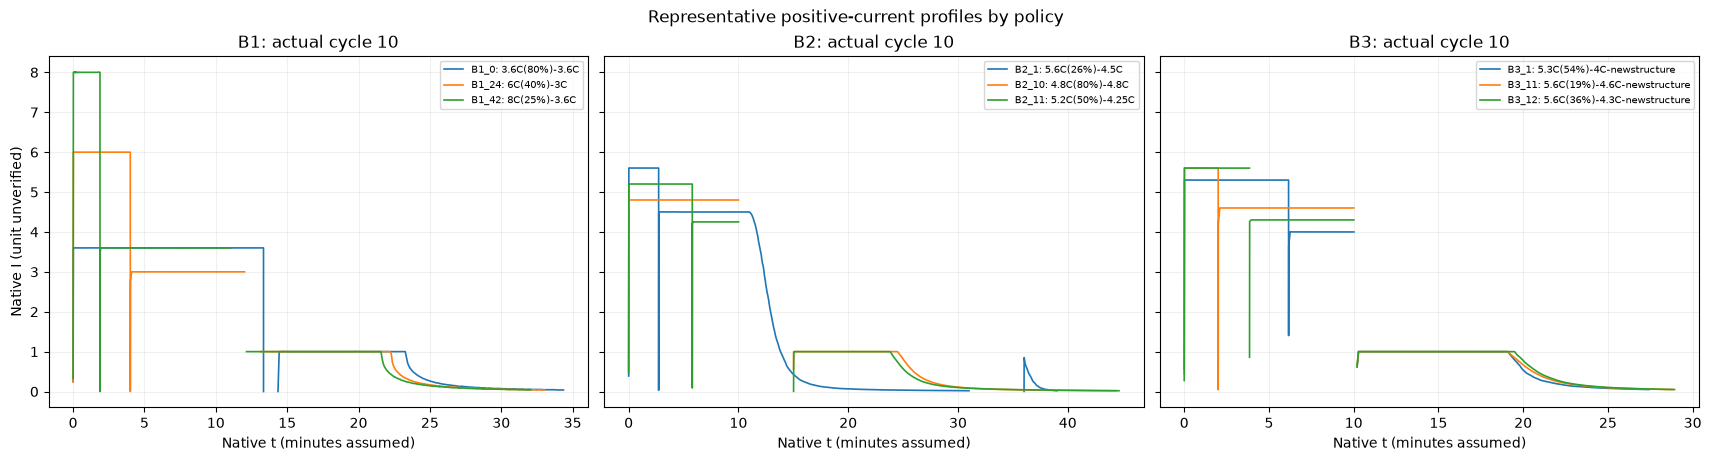

,batch_id,cell_uid,charging_policy,actual_cycle
0,B1,B1_0,3.6C(80%)-3.6C,10
1,B1,B1_24,6C(40%)-3C,10
2,B1,B1_42,8C(25%)-3.6C,10
3,B2,B2_1,5.6C(26%)-4.5C,10
4,B2,B2_10,4.8C(80%)-4.8C,10
5,B2,B2_11,5.2C(50%)-4.25C,10
6,B3,B3_1,5.3C(54%)-4C-newstructure,10
7,B3,B3_11,5.6C(19%)-4.6C-newstructure,10
8,B3,B3_12,5.6C(36%)-4.3C-newstructure,10


,batch_id,feature,target,n_pairs,excluded_n,spearman_rho,status
0,B1,C1,early_QD_slope,46,0,-0.380287,ok
1,B1,SOC_switch_pct,early_QD_slope,46,0,0.101991,ok
2,B1,C2,early_QD_slope,46,0,-0.058811,ok
3,B1,charge_I_mean,early_QD_slope,46,0,-0.309282,ok
4,B1,charge_I_peak,early_QD_slope,46,0,-0.380462,ok
5,B1,charge_I_std,early_QD_slope,46,0,-0.548689,ok
6,B1,C1,life,46,0,-0.482714,ok
7,B1,SOC_switch_pct,life,46,0,0.185159,ok
8,B1,C2,life,46,0,0.047414,ok
9,B1,charge_I_mean,life,46,0,-0.513260,ok


,batch_id,relative_speed,batch_median_native_I,cell_n,valid_life_n,policy_n,policies_in_both_groups_n,mean_native_I,life_mean,life_sample_sd
0,B1,higher_or_equal_median_I,1.907241,23,23,13,3,1.960602,769.652174,136.967683
1,B1,lower_than_median_I,1.907241,23,23,13,3,1.855754,919.782609,197.947871
2,B1,unavailable_current,1.907241,0,0,0,3,NaN,NaN,NaN
3,B2,higher_or_equal_median_I,1.644089,24,21,11,4,2.124808,664.857143,264.852088
4,B2,lower_than_median_I,1.644089,23,18,13,4,1.491307,450.111111,39.328016
5,B2,unavailable_current,1.644089,0,0,0,4,NaN,NaN,NaN
6,B3,higher_or_equal_median_I,2.154630,23,23,7,6,2.210867,1055.173913,288.897379
7,B3,lower_than_median_I,2.154630,23,21,7,6,2.109375,1064.571429,346.336768
8,B3,unavailable_current,2.154630,0,0,0,6,NaN,NaN,NaN


In [21]:
# Up to three frequent policies per batch, one cell per policy, always actual cycle 10.
_q4_profile_representatives = []
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True, constrained_layout=True)
for ax, batch in zip(axes, BATCH_ORDER):
    part = current_features.loc[current_features['batch_id'] == batch]
    available = part.loc[[((uid, 10) in current_profiles) for uid in part.index]]
    policies = available['charging_policy'].value_counts().head(3).index
    for policy in policies:
        same_policy = available.loc[available['charging_policy'] == policy]
        # Selection is independent of life: stable lexical uid order.
        uid = sorted(same_policy.index.astype(str))[0]
        profile = current_profiles[(uid, 10)]
        ax.plot(profile['t'], profile['I'], linewidth=1.2, label=f'{uid}: {policy}')
        _q4_profile_representatives.append({'batch_id': batch, 'cell_uid': uid,
            'charging_policy': policy, 'actual_cycle': 10})
    ax.set(title=f'{batch}: actual cycle 10', xlabel='Native t (minutes assumed)')
    ax.grid(alpha=0.18)
    if len(policies):
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, 'No current profile', ha='center', va='center', transform=ax.transAxes)
axes[0].set_ylabel('Native I (unit unverified)')
fig.suptitle('Representative positive-current profiles by policy')
plt.show()
display(pd.DataFrame(_q4_profile_representatives))

_q4_assoc_rows = []
for batch in BATCH_ORDER:
    part = current_features.loc[current_features['batch_id'] == batch]
    for target in ['early_QD_slope', 'life']:
        for feature in ['C1', 'SOC_switch_pct', 'C2', 'charge_I_mean', 'charge_I_peak', 'charge_I_std']:
            pairs = part[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
            status = 'ok'
            if len(pairs) < 3:
                status = 'fewer_than_3_pairs'
            elif pairs[feature].nunique() < 2 or pairs[target].nunique() < 2:
                status = 'constant_variable'
            _q4_assoc_rows.append({'batch_id': batch, 'feature': feature, 'target': target,
                'n_pairs': len(pairs), 'excluded_n': len(part) - len(pairs),
                'spearman_rho': pairs[feature].corr(pairs[target], method='spearman') if status == 'ok' else np.nan,
                'status': status})
current_associations = pd.DataFrame(_q4_assoc_rows)
associations = current_associations
display(current_associations)

# Fast/slower is relative to each batch's median native-I mean, not an absolute C threshold.
_q4_speed_rows = []
for batch in BATCH_ORDER:
    part = current_features.loc[current_features['batch_id'] == batch].copy()
    finite = np.isfinite(part['charge_I_mean'])
    median_I = float(part.loc[finite, 'charge_I_mean'].median()) if finite.any() else np.nan
    part['relative_speed'] = 'unavailable_current'
    part.loc[finite & (part['charge_I_mean'] >= median_I), 'relative_speed'] = 'higher_or_equal_median_I'
    part.loc[finite & (part['charge_I_mean'] < median_I), 'relative_speed'] = 'lower_than_median_I'
    fast_policies = set(part.loc[part['relative_speed'] == 'higher_or_equal_median_I', 'charging_policy'])
    slow_policies = set(part.loc[part['relative_speed'] == 'lower_than_median_I', 'charging_policy'])
    overlap = len(fast_policies & slow_policies)
    for group in ['higher_or_equal_median_I', 'lower_than_median_I', 'unavailable_current']:
        sample = part.loc[part['relative_speed'] == group]
        _q4_speed_rows.append({'batch_id': batch, 'relative_speed': group,
            'batch_median_native_I': median_I, 'cell_n': len(sample),
            'valid_life_n': int(sample['life'].notna().sum()),
            'policy_n': sample['charging_policy'].nunique(), 'policies_in_both_groups_n': overlap,
            'mean_native_I': sample['charge_I_mean'].mean(),
            'life_mean': sample['life'].mean(), 'life_sample_sd': sample['life'].std(ddof=1)})
current_speed_life_stats = pd.DataFrame(_q4_speed_rows)
speed_stats = current_speed_life_stats
display(current_speed_life_stats)

해석 시 배치별 정책 수·셀 수·전환 SOC·C2·환경 및 후반 CC-CV 비중이 함께 달라진다는 점을 고려한다.
위의 빠름/느림은 **배치 내 native-I 평균 중앙값** 기준이며, 같은 정책이 양쪽에 존재하는 수도 표시한다.
셀 반복수가 적은 정책, n=0/1 집단, 단위 미확인 전류는 통계의 범위를 제한한다.
상관계수와 수명 평균 차이만으로 충전 속도의 인과효과를 확정할 수 없다.

## 5. 초기 피처와 수명 — 관계·배치 차이·다중공선성

실제 초기 100사이클의 Summary 피처와 `ΔQ(V)=Q100(V)−Q10(V)` 피처를 **cell_uid당 한 행**으로
결합한다. 배치별 Pearson/Spearman과 표본 수를 확인하고, 타깃 관계와 피처 간 중복을 따로 본다.
전체 파일을 섞은 상관과 각 배치의 평균을 제거한 상관을 비교해 배치 간 기준 수준 차이의 영향을 점검한다.

VIF는 타깃·ID·배치 라벨을 입력에서 제외하고 모든 시나리오에서 **동일한 완전 관측 셀**을 사용한다.
상관 및 VIF 감소는 예측 성능의 개선을 입증하지 않는다. 남아 있는 이상값과 작은 표본의 영향도 고려한다.

In [22]:
q5_summary_features = ['mean_QD','std_QD','early_QD_slope','mean_IR','mean_Tavg','mean_Tmax','mean_chargetime']
q5_delta_features = ['delta_q_var','log10_delta_q_var','delta_q_min']
q5_features = q5_summary_features + q5_delta_features
q5_meta = cells_all.set_index('cell_uid')[['batch_id','cycle_life']].copy()
assert q5_meta.index.is_unique and early_raw.index.is_unique and early_clean.index.is_unique and dq_features.index.is_unique
q5_data = q5_meta.join(early_clean[q5_summary_features], validate='one_to_one').join(
    dq_features[q5_delta_features], validate='one_to_one')
q5_raw_data = q5_meta.join(early_raw[q5_summary_features], validate='one_to_one').join(
    dq_features[q5_delta_features], validate='one_to_one')
for q5_table in (q5_data, q5_raw_data):
    q5_table[q5_features + ['cycle_life']] = q5_table[q5_features + ['cycle_life']].apply(
        pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
    q5_table.loc[q5_table.cycle_life <= 0, 'cycle_life'] = np.nan
display(q5_data.head().round(6))
display(q5_data.groupby('batch_id')[q5_features + ['cycle_life']].count().reindex(BATCH_ORDER))

q5_reason_table = pd.DataFrame([
    ('mean_QD','초기 QD 평균','초기 용량 수준; 작은 셀 차이 확인','스파이크·활성화 영향'),
    ('std_QD','초기 QD 표본 표준편차 (ddof=1)','초기 변동 정도','0행·용량 스파이크 영향'),
    ('early_QD_slope','초기 QD~실제 cycle 선형 기울기','초기 용량 변화 속도','양의 기울기 가능; 이상값 민감'),
    ('mean_IR','유효 초기 IR 평균','초기 저항 수준','IR≤0은 결측; 유효 행 수 확인'),
    ('mean_Tavg','초기 평균 온도의 평균','열 조건과 수명 관계 탐색','배치 조건·온도 오류 영향'),
    ('mean_Tmax','초기 최고 온도의 평균','최고 온도 조건 탐색','Tavg와 중복 가능'),
    ('mean_chargetime','초기 충전 시간 평균','충전 조건의 관측 신호','긴 시간 이상값·정책 혼재'),
    ('delta_q_var','Var[Q100(V)−Q10(V)] (ddof=0)','초기 방전 곡선 변화의 분산','원시 분산의 치우침·다른 ΔQ 피처와 중복'),
    ('log10_delta_q_var','log10(ΔQ 분산)','변화 크기의 넓은 범위를 압축','분산>0 필요; 순위는 원시 분산과 동일'),
    ('delta_q_min','min_V[Q100(V)−Q10(V)]','가장 큰 음의 곡선 변화','부호 해석·전압 축·단일 점 민감성'),
], columns=['feature','calculation','reason','check']).set_index('feature')
display(q5_reason_table)

,batch_id,cycle_life,mean_QD,std_QD,early_QD_slope,mean_IR,mean_Tavg,mean_Tmax,mean_chargetime,delta_q_var,log10_delta_q_var,delta_q_min
cell_uid,,,,,,,,,,,,
B1_0,B1,1190.0,1.080597,0.046562,-0.000207,0.016643,31.603747,35.376748,13.384231,0.000010,-5.014861,-0.008460
B1_1,B1,1179.0,1.081247,0.001191,0.000006,0.016922,31.330314,34.160655,13.374696,0.000010,-5.013960,-0.011004
B1_2,B1,1177.0,1.085371,0.001026,0.000010,0.016769,31.479584,34.544644,13.378886,0.000018,-4.737000,-0.017216
B1_3,B1,1226.0,1.084949,0.001096,0.000017,0.016311,29.942199,30.662263,12.053277,0.000036,-4.442613,-0.018961
B1_4,B1,1227.0,1.082844,0.001095,0.000019,0.016669,31.448884,34.382516,12.053314,0.000023,-4.647744,-0.013958


,mean_QD,std_QD,early_QD_slope,mean_IR,mean_Tavg,mean_Tmax,mean_chargetime,delta_q_var,log10_delta_q_var,delta_q_min,cycle_life
batch_id,,,,,,,,,,,
B1,46,46,46,46,46,46,46,46,46,46,46
B2,47,47,47,40,47,47,47,47,47,47,39
B3,46,46,46,46,46,46,46,46,46,46,44


,calculation,reason,check
feature,,,
mean_QD,초기 QD 평균,초기 용량 수준; 작은 셀 차이 확인,스파이크·활성화 영향
std_QD,초기 QD 표본 표준편차 (ddof=1),초기 변동 정도,0행·용량 스파이크 영향
early_QD_slope,초기 QD~실제 cycle 선형 기울기,초기 용량 변화 속도,양의 기울기 가능; 이상값 민감
mean_IR,유효 초기 IR 평균,초기 저항 수준,IR≤0은 결측; 유효 행 수 확인
mean_Tavg,초기 평균 온도의 평균,열 조건과 수명 관계 탐색,배치 조건·온도 오류 영향
mean_Tmax,초기 최고 온도의 평균,최고 온도 조건 탐색,Tavg와 중복 가능
mean_chargetime,초기 충전 시간 평균,충전 조건의 관측 신호,긴 시간 이상값·정책 혼재
delta_q_var,Var[Q100(V)−Q10(V)] (ddof=0),초기 방전 곡선 변화의 분산,원시 분산의 치우침·다른 ΔQ 피처와 중복
log10_delta_q_var,log10(ΔQ 분산),변화 크기의 넓은 범위를 압축,분산>0 필요; 순위는 원시 분산과 동일


In [23]:
def q5_correlations(source, scenario):
    rows = []
    for scope in [*BATCH_ORDER, 'All files', 'Within batch (centered)']:
        part = source.loc[source.batch_id == scope] if scope in BATCH_ORDER else source
        for feature in q5_features:
            pair = part[['batch_id',feature,'cycle_life']].dropna().copy()
            if scope == 'Within batch (centered)':
                # Center target and feature on the same complete pairs in each batch.
                numeric = pair[[feature,'cycle_life']]
                pair[[feature,'cycle_life']] = numeric - pair.groupby('batch_id')[[feature,'cycle_life']].transform('mean')
            supported = len(pair) >= 3 and pair[feature].nunique() > 1 and pair.cycle_life.nunique() > 1
            rows.append({'scenario':scenario, 'scope':scope, 'feature':feature, 'n_pairs':len(pair),
                         'Pearson':pair[feature].corr(pair.cycle_life) if supported else np.nan,
                         'Spearman':pair[feature].corr(pair.cycle_life, method='spearman') if supported else np.nan})
    return pd.DataFrame(rows)

q5_corr_clean = q5_correlations(q5_data, 'clean scenario')
q5_corr_raw = q5_correlations(q5_raw_data, 'raw summary')
q5_corr_all = pd.concat([q5_corr_raw, q5_corr_clean], ignore_index=True)
for q5_name in BATCH_ORDER:
    q5_rank = q5_corr_clean.loc[q5_corr_clean.scope == q5_name].set_index('feature')
    q5_rank = q5_rank[['n_pairs','Pearson','Spearman']].sort_values('Pearson', key=lambda s:s.abs(), ascending=False)
    print(f'{q5_name}: absolute Pearson ranking (not a model ranking)')
    display(q5_rank.round(4))
q5_comparison = q5_corr_clean.loc[q5_corr_clean.scope.isin(['All files','Within batch (centered)'])].pivot(
    index='feature', columns='scope', values=['n_pairs','Pearson','Spearman'])
display(q5_comparison.reindex(q5_features).round(4))
q5_raw_clean_comparison = q5_corr_all.loc[q5_corr_all.scope.isin(BATCH_ORDER)].pivot(
    index=['scope','feature'], columns='scenario', values=['n_pairs','Pearson','Spearman'])
display(q5_raw_clean_comparison.round(4))
print('Within-batch Spearman은 배치 평균 제거 후 잔차의 순위 상관입니다; 배치별 Spearman 평균과 다릅니다.')

B1: absolute Pearson ranking (not a model ranking)


,n_pairs,Pearson,Spearman
feature,,,
log10_delta_q_var,46,-0.8861,-0.8712
delta_q_min,46,0.8816,0.8500
delta_q_var,46,-0.8378,-0.8712
mean_chargetime,46,0.5770,0.6131
mean_Tavg,46,-0.4818,-0.3715
mean_Tmax,46,-0.4036,-0.3230
mean_IR,46,0.2180,0.1890
mean_QD,46,0.1934,0.1850
early_QD_slope,46,0.1838,0.4809


B2: absolute Pearson ranking (not a model ranking)


,n_pairs,Pearson,Spearman
feature,,,
log10_delta_q_var,39,-0.9019,-0.7090
delta_q_min,39,0.8185,0.6609
delta_q_var,39,-0.7328,-0.7090
mean_IR,33,-0.6270,-0.1992
early_QD_slope,39,-0.4398,-0.2640
mean_Tavg,39,0.4246,0.1760
mean_QD,39,-0.3321,0.1119
std_QD,39,0.1707,-0.1134
mean_chargetime,39,0.0870,-0.3868


B3: absolute Pearson ranking (not a model ranking)


,n_pairs,Pearson,Spearman
feature,,,
log10_delta_q_var,44,-0.7019,-0.7972
delta_q_min,44,0.6921,0.7760
mean_chargetime,44,0.6375,0.1964
delta_q_var,44,-0.5897,-0.7972
std_QD,44,-0.3562,-0.3548
early_QD_slope,44,0.3330,0.0527
mean_QD,44,0.2175,0.1622
mean_IR,44,0.1902,0.1687
mean_Tmax,44,-0.1065,-0.0351


n_pairs                           Pearson                          Spearman                        
scope             All files Within batch (centered) All files Within batch (centered) All files Within batch (centered)
feature                                                                                                                
mean_QD               129.0                   129.0   -0.5004                  0.0183   -0.5123                  0.0900
std_QD                129.0                   129.0   -0.0704                 -0.0259   -0.5114                 -0.1120
early_QD_slope        129.0                   129.0   -0.0899                  0.0212   -0.1718                  0.0526
mean_IR               123.0                   123.0   -0.3363                 -0.0372   -0.3595                  0.0129
mean_Tavg             129.0                   129.0    0.2384                  0.0017    0.1898                  0.0096
mean_Tmax             129.0                   129.0   -0.0167                 -0.1405   -0.0115                 -0.1089
mean_chargetime       129.0                   129.0   -0.1939                  0.0757   -0.1321                  0.2057
delta_q_var           129.0                   129.0   -0.7498                 -0.6001   -0.8921                 -0.7547
log10_delta_q_var     129.0                   129.0   -0.8506                 -0.7731   -0.8921                 -0.8019
delta_q_min           129.0                   129.0    0.8273                  0.7204    0.8834                  0.7728

n_pairs                    Pearson                   Spearman            
scenario                clean scenario raw summary clean scenario raw summary clean scenario raw summary
scope feature                                                                                           
B1    delta_q_min                 46.0        46.0         0.8816      0.8816         0.8500      0.8500
      delta_q_var                 46.0        46.0        -0.8378     -0.8378        -0.8712     -0.8712
      early_QD_slope              46.0        46.0         0.1838      0.1838         0.4809      0.4809
      log10_delta_q_var           46.0        46.0        -0.8861     -0.8861        -0.8712     -0.8712
      mean_IR                     46.0        46.0         0.2180      0.1766         0.1890      0.1355
      mean_QD                     46.0        46.0         0.1934      0.1934         0.1850      0.1850
      mean_Tavg                   46.0        46.0        -0.4818     -0.4818        -0.3715     -0.3715
      mean_Tmax                   46.0        46.0        -0.4036     -0.4036        -0.3230     -0.3230
      mean_chargetime             46.0        46.0         0.5770      0.5770         0.6131      0.6131
      std_QD                      46.0        46.0        -0.0585     -0.0900         0.0528      0.2367
B2    delta_q_min                 39.0        39.0         0.8185      0.8185         0.6609      0.6609
      delta_q_var                 39.0        39.0        -0.7328     -0.7328        -0.7090     -0.7090
      early_QD_slope              39.0        39.0        -0.4398     -0.4398        -0.2640     -0.2640
      log10_delta_q_var           39.0        39.0        -0.9019     -0.9019        -0.7090     -0.7090
      mean_IR                     33.0        39.0        -0.6270     -0.3525        -0.1992     -0.3456
      mean_QD                     39.0        39.0        -0.3321     -0.3321         0.1119      0.1119
      mean_Tavg                   39.0        39.0         0.4246      0.4246         0.1760      0.1760
      mean_Tmax                   39.0        39.0         0.0190      0.0190        -0.1359     -0.1359
      mean_chargetime             39.0        39.0         0.0870      0.0870        -0.3868     -0.3868
      std_QD                      39.0        39.0         0.1707      0.1707        -0.1134     -0.1134
B3    delta_q_min                 44.0        44.0         0.6921      0.6921         0.7760      0.7760
      delta_q_var                 44.0        44.0        -0.5897     -0.5897        -0.7972     -0.7972
      early_QD_slope              44.0        44.0         0.3330      0.3330         0.0527      0.0527
      log10_delta_q_var           44.0        44.0        -0.7019     -0.7019        -0.7972     -0.7972
      mean_IR                     44.0        44.0         0.1902      0.1902         0.1687      0.1687
      mean_QD                     44.0        44.0         0.2175      0.2175         0.1622      0.1622
      mean_Tavg                   44.0        44.0        -0.0218     -0.0218         0.0254      0.0254
      mean_Tmax                   44.0        44.0        -0.1065     -0.1065        -0.0351     -0.0351
      mean_chargetime             44.0        44.0         0.6375      0.6375         0.1964      0.1964
      std_QD                      44.0        44.0        -0.3562     -0.3562        -0.3548     -0.3548

Within-batch Spearman은 배치 평균 제거 후 잔차의 순위 상관입니다; 배치별 Spearman 평균과 다릅니다.


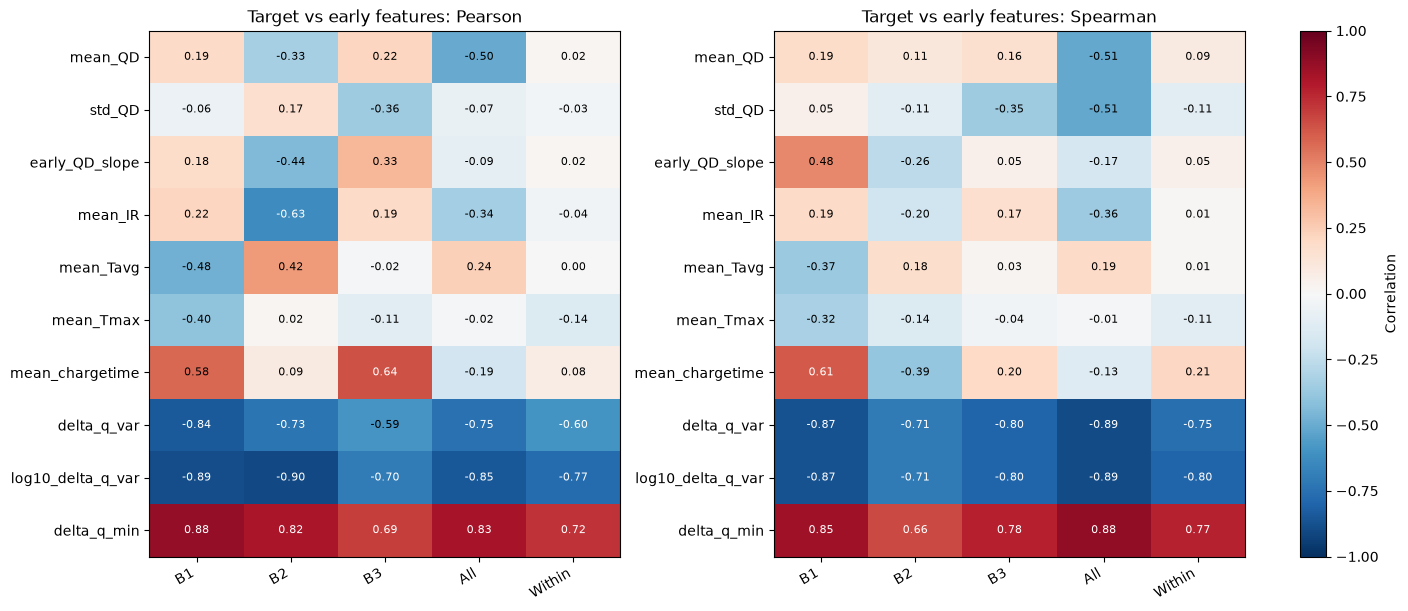

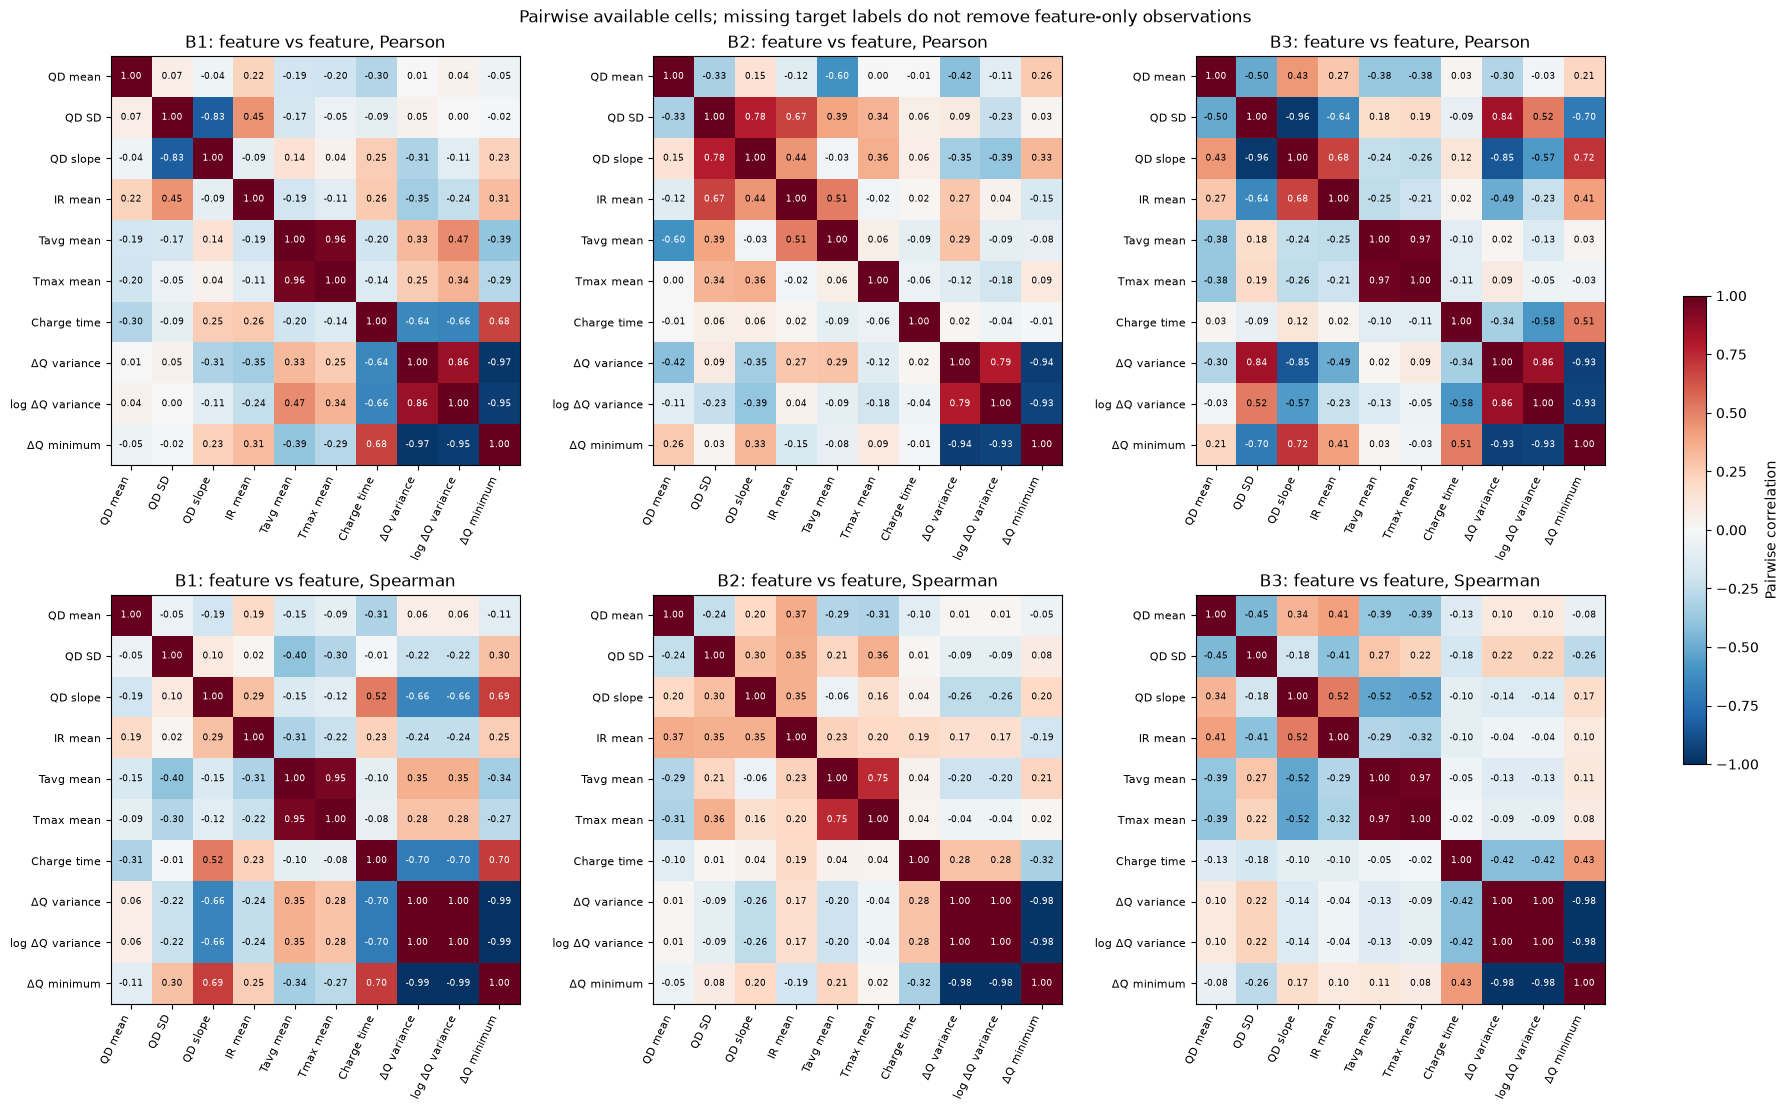

In [24]:
# 타깃 관계와 피처 간 관계를 별도 그림으로 표시한다.
q5_scopes = [*BATCH_ORDER, 'All files', 'Within batch (centered)']
fig, q5_axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for q5_ax, q5_method in zip(q5_axes, ['Pearson','Spearman']):
    q5_matrix = q5_corr_clean.pivot(index='feature', columns='scope', values=q5_method).reindex(
        index=q5_features, columns=q5_scopes)
    q5_im = q5_ax.imshow(np.ma.masked_invalid(q5_matrix.to_numpy()), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    q5_ax.set_xticks(range(len(q5_scopes)), ['B1','B2','B3','All','Within'], rotation=30, ha='right')
    q5_ax.set_yticks(range(len(q5_features)), q5_features)
    q5_ax.set_title(f'Target vs early features: {q5_method}')
    for q5_i in range(len(q5_features)):
        for q5_j in range(len(q5_scopes)):
            q5_v = q5_matrix.iloc[q5_i,q5_j]
            q5_ax.text(q5_j,q5_i,f'{q5_v:.2f}' if np.isfinite(q5_v) else 'NA', ha='center', va='center',
                       fontsize=8, color='white' if np.isfinite(q5_v) and abs(q5_v)>.6 else 'black')
fig.colorbar(q5_im, ax=q5_axes, fraction=.025, label='Correlation')
plt.show()

q5_short_labels = ['QD mean','QD SD','QD slope','IR mean','Tavg mean','Tmax mean','Charge time',
                   'ΔQ variance','log ΔQ variance','ΔQ minimum']
fig, q5_axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
for q5_col, q5_name in enumerate(BATCH_ORDER):
    q5_part = q5_data.loc[q5_data.batch_id == q5_name, q5_features]
    for q5_row, q5_method in enumerate(['pearson','spearman']):
        q5_ax = q5_axes[q5_row,q5_col]
        q5_matrix = q5_part.corr(method=q5_method, min_periods=3)
        q5_im = q5_ax.imshow(np.ma.masked_invalid(q5_matrix.to_numpy()), cmap='RdBu_r', vmin=-1, vmax=1)
        q5_ax.set_xticks(range(len(q5_features)), q5_short_labels, rotation=65, ha='right', fontsize=8)
        q5_ax.set_yticks(range(len(q5_features)), q5_short_labels, fontsize=8)
        q5_ax.set_title(f'{q5_name}: feature vs feature, {q5_method.title()}')
        for q5_i in range(len(q5_features)):
            for q5_j in range(len(q5_features)):
                q5_v = q5_matrix.iloc[q5_i,q5_j]
                q5_ax.text(q5_j,q5_i,f'{q5_v:.2f}' if np.isfinite(q5_v) else 'NA', ha='center', va='center',
                           fontsize=6.5, color='white' if np.isfinite(q5_v) and abs(q5_v)>.6 else 'black')
fig.colorbar(q5_im, ax=q5_axes, fraction=.015, label='Pairwise correlation')
fig.suptitle('Pairwise available cells; missing target labels do not remove feature-only observations')
plt.show()

In [25]:
def q5_vif(x):
    # Intercept included; standardized features; complete rows supplied by caller.
    x = x.astype(float)
    scale = x.std(ddof=0)
    constant = scale.index[(~np.isfinite(scale)) | (scale <= np.finfo(float).eps)].tolist()
    use = [col for col in x if col not in constant]
    result = pd.Series(np.nan, index=x.columns, dtype=float, name='VIF')
    status = {'n_cells':len(x), 'n_input_features':len(x.columns),
              'n_variable_features':len(use), 'constant_features':', '.join(constant), 'status':'ok'}
    if not use or len(x) <= len(use) + 1:
        status['status'] = 'insufficient cells for this feature set'
        return result, status
    z = (x[use] - x[use].mean()) / scale[use]
    for col in use:
        target = z[col].to_numpy()
        others = z.drop(columns=col).to_numpy()
        design = np.column_stack([np.ones(len(z)), others])
        beta = np.linalg.lstsq(design, target, rcond=None)[0]
        sst = np.square(target - target.mean()).sum()
        fraction = np.square(target - design @ beta).sum() / sst
        result[col] = 1/fraction if fraction > 1e-12 else np.inf
    if constant:
        status['status'] = 'constant features excluded (VIF shown as NA)'
    return result, status

q5_vif_scenarios = {
    'All candidates': [],
    'Drop Tmax': ['mean_Tmax'],
    'Drop raw var': ['delta_q_var'],
    'Drop Tmax + raw var': ['mean_Tmax','delta_q_var'],
    'Logvar representative': ['mean_Tmax','delta_q_var','delta_q_min'],
    'Min representative': ['mean_Tmax','delta_q_var','log10_delta_q_var'],
}
q5_vif_tables, q5_vif_support, q5_vif_statuses = {}, [], []
for q5_name in [*BATCH_ORDER, 'All files']:
    q5_part = q5_data.loc[q5_data.batch_id == q5_name] if q5_name in BATCH_ORDER else q5_data
    # The complete-case cohort is fixed BEFORE dropping candidate features.
    q5_common = q5_part.dropna(subset=q5_features + ['cycle_life'])
    q5_vif_support.append({'scope':q5_name, 'total_cells':len(q5_part),
                           'valid_life':int(q5_part.cycle_life.notna().sum()),
                           'same_complete_cases':len(q5_common)})
    q5_table = {}
    for q5_scenario, q5_drop in q5_vif_scenarios.items():
        q5_keep = [col for col in q5_features if col not in q5_drop]
        q5_values, q5_status = q5_vif(q5_common[q5_keep])
        q5_table[q5_scenario] = q5_values
        q5_vif_statuses.append({'scope':q5_name,'scenario':q5_scenario,**q5_status})
    q5_vif_tables[q5_name] = pd.DataFrame(q5_table).reindex(q5_features)
display(pd.DataFrame(q5_vif_support).set_index('scope'))
for q5_name, q5_table in q5_vif_tables.items():
    print(f'{q5_name}: VIF comparisons use the same cells in all six scenarios')
    display(q5_table.round(3))
q5_vif_status = pd.DataFrame(q5_vif_statuses)
q5_bad_status = q5_vif_status.loc[q5_vif_status.status != 'ok']
if len(q5_bad_status):
    display(q5_bad_status)
print('NA는 시나리오에서 제외한 피처 또는 계산 불가 피처입니다; 무한대는 선형 중복을 뜻합니다.')

,total_cells,valid_life,same_complete_cases
scope,,,
B1,46,46,46
B2,47,39,33
B3,46,44,44
All files,139,129,123


B1: VIF comparisons use the same cells in all six scenarios


,All candidates,Drop Tmax,Drop raw var,Drop Tmax + raw var,Logvar representative,Min representative
mean_QD,1.556,1.556,1.361,1.351,1.350,1.347
std_QD,7.781,7.631,7.778,7.610,5.989,6.163
early_QD_slope,7.341,7.340,7.336,7.333,4.923,5.214
mean_IR,2.259,2.213,2.232,2.198,2.195,2.195
mean_Tavg,25.236,1.457,23.874,1.453,1.428,1.344
mean_Tmax,20.884,NaN,19.820,NaN,NaN,NaN
mean_chargetime,2.363,2.346,2.359,2.338,2.333,2.267
delta_q_var,73.360,69.624,NaN,NaN,NaN,NaN
log10_delta_q_var,38.579,38.106,19.606,16.666,2.256,NaN
delta_q_min,175.319,171.873,18.134,17.136,NaN,2.319


B2: VIF comparisons use the same cells in all six scenarios


,All candidates,Drop Tmax,Drop raw var,Drop Tmax + raw var,Logvar representative,Min representative
mean_QD,2.237,2.237,2.040,2.039,1.768,1.787
std_QD,1.320,1.276,1.312,1.268,1.268,1.268
early_QD_slope,3.179,3.134,3.092,3.048,1.605,1.790
mean_IR,3.010,2.786,3.004,2.780,2.346,2.133
mean_Tavg,5.321,1.341,5.294,1.314,1.245,1.222
mean_Tmax,4.597,NaN,4.597,NaN,NaN,NaN
mean_chargetime,1.581,1.555,1.510,1.483,1.314,1.324
delta_q_var,67.667,67.667,NaN,NaN,NaN,NaN
log10_delta_q_var,92.817,85.325,71.605,64.136,1.877,NaN
delta_q_min,223.181,220.241,63.424,60.525,NaN,1.771


B3: VIF comparisons use the same cells in all six scenarios


,All candidates,Drop Tmax,Drop raw var,Drop Tmax + raw var,Logvar representative,Min representative
mean_QD,1.925,1.916,1.909,1.893,1.846,1.769
std_QD,21.853,21.761,18.388,18.376,16.802,17.055
early_QD_slope,19.732,19.676,19.666,19.632,19.410,17.958
mean_IR,2.297,2.197,2.277,2.191,2.072,1.940
mean_Tavg,27.874,1.716,26.769,1.710,1.710,1.643
mean_Tmax,25.307,NaN,24.075,NaN,NaN,NaN
mean_chargetime,2.305,2.222,2.114,1.959,1.934,1.830
delta_q_var,28.132,26.763,NaN,NaN,NaN,NaN
log10_delta_q_var,17.573,17.128,13.111,11.761,3.429,NaN
delta_q_min,16.545,15.900,14.113,13.891,NaN,4.050


All files: VIF comparisons use the same cells in all six scenarios


,All candidates,Drop Tmax,Drop raw var,Drop Tmax + raw var,Logvar representative,Min representative
mean_QD,2.839,2.823,2.828,2.811,2.640,2.798
std_QD,1.867,1.858,1.867,1.858,1.792,1.831
early_QD_slope,2.398,2.398,2.398,2.398,2.094,2.257
mean_IR,2.395,2.124,2.394,2.123,2.122,2.123
mean_Tavg,8.491,1.534,8.488,1.533,1.533,1.530
mean_Tmax,6.552,NaN,6.551,NaN,NaN,NaN
mean_chargetime,1.193,1.168,1.178,1.152,1.086,1.096
delta_q_var,25.900,25.895,NaN,NaN,NaN,NaN
log10_delta_q_var,20.655,20.599,13.971,13.929,1.586,NaN
delta_q_min,71.271,70.776,16.040,15.668,NaN,1.784


NA는 시나리오에서 제외한 피처 또는 계산 불가 피처입니다; 무한대는 선형 중복을 뜻합니다.


**후보 선정의 근거와 다음 검증:** 계산식과 생성 이유를 먼저 기록하고, 배치별 타깃 관계가 일관적인지,
원본/정제 및 Pearson/Spearman 결과가 얼마나 달라지는지 확인한다. 전체 상관이 배치 내 상관과 다르면
배치의 기준 수준이나 실험 조건 차이가 관계에 섞였을 가능성을 점검한다. 이는 인과 효과의 확인이 아니다.

온도 피처의 VIF가 크면 평균/최고 온도를 각각 대표로 쓴 후보를 비교할 수 있다. 원시 ΔQ 분산과 로그 분산은
순위를 공유하므로 둘을 동시에 유지할 이유를 검토한다. 위 `Logvar representative`와 `Min representative`는
나머지 피처와 표본을 고정한 **후보 비교**다. 배치별 안정성·측정 품질·모델 목적을 함께 고려하며, 높은 상관이나
낮아진 VIF만으로 최종 피처를 확정하지 않는다.

최종 전처리·피처 선택은 학습 폴드 안에서 수행하고, 물리적 셀 식별과 배치 차이를 고려한 검증에서
추가·제거에 따른 예측 오차를 비교한다. 전체 수명 곡선에서 계산한 Knee·후기 IR 등은 초기 100사이클
예측 입력에 포함하지 않는다.

분산과 로그 분산의 순위 동일성은 변환 전 배치별 데이터에서 성립한다. 피처별 배치 평균을 제거한 뒤의 잔차 순위는 서로 달라질 수 있다.

피처 간 히트맵은 타깃 결측 셀도 포함한 쌍별 가용 표본이고, VIF는 타깃과 모든 후보가 완전 관측된 고정 표본이다. 특히 B2에서 두 표본의 온도 상관이 다를 수 있으므로 표본 수와 함께 해석한다.

## 결과를 읽고 과제에 기록하는 순서

각 질문의 출력에서 **관찰된 값 → 가능한 설명 → 확인할 한계**를 구분한다. 단수명 셀의 정책·온도·초기 열화가
다른 것은 원인 후보를 제시하지만 원인을 입증하지 않는다. 상관이 큰 피처도 미래 예측 성능을 보장하지 않는다.

피처 선정은 생성 식과 이유를 적고, 원본/정제·배치별 관계를 비교한 뒤 중복 피처를 제거한다.
다음 모델 단계에서는 셀 단위 분할을 사용하고, 동일 물리셀인지 확인한 뒤 배치 외 검증을 수행한다.
EDA에 사용해 피처를 선택한 배치를 최종 미사용 테스트라고 보고하지 않는다.
전처리·스케일링·피처 선정은 학습 폴드 안에서 결정하고 검증 MAE/RMSE로 추가·제거 효과를 확인한다.
Knee·전체 사이클 수·마지막 용량은 초기 예측 모델에서 제외한다.

### 분석 결과 저장

재사용할 표를 `results/five_questions/`에 저장한다. 원본 `.mat`은 입력 데이터로 사용한다.
아래 마지막 표는 다섯 질문을 배치별로 검토하는 출발점이며 세부 결론은 각 위 그래프·표와 함께 읽는다.

In [26]:
OUT_DIR = ROOT / 'results/five_questions'
OUT_DIR.mkdir(parents=True,exist_ok=True)
q2_knee_export = q2_knee_results.merge(knee_stability.reset_index(),on=['batch_id','cell_id'],how='left',validate='one_to_one')
exports = {'summary_raw.csv':eda_raw,'summary_clean_scenario.csv':eda_clean,
    'cell_metadata.csv':cells_all,'early100_features.csv':early_clean,
    'delta_q_features.csv':dq_features,'current_features.csv':current_features,
    'knee_candidates.csv':q2_knee_export,'knee_sensitivity.csv':knee_sensitivity,
    'knee_stability.csv':knee_stability,
    'life_distribution.csv':q1_stats,'short_life_investigation.csv':q1_investigate,
    'feature_target_correlations.csv':q5_corr_all,'vif_support.csv':pd.DataFrame(q5_vif_support),
    'vif_status.csv':q5_vif_status,'policy_life_stats.csv':policy_life_stats,
    'current_cycle_features.csv':current_cycle_features,'current_associations.csv':current_associations,
    'current_speed_life_stats.csv':current_speed_life_stats,'delta_q_group_counts.csv':dq_group_counts}
for name,table in exports.items():
    table.to_csv(OUT_DIR/name,index=table.index.name is not None or isinstance(table.index,pd.MultiIndex))
for scope,table in q5_vif_tables.items():
    table.to_csv(OUT_DIR/f'vif_{scope.replace(" ","_")}.csv')
comparison_rows=[]
for batch in BATCH_ORDER:
    meta=cells_all.loc[cells_all.batch_id==batch]
    life=meta.cycle_life.dropna()
    dq=dq_features.loc[dq_features.batch_id==batch]
    knee=q2_knee_export.loc[q2_knee_export.batch_id==batch]
    comparison_rows.append({'batch_id':batch,'records':len(meta),'valid_life':len(life),
        'missing_life':int(meta.cycle_life.isna().sum()),'median_life':life.median(),
        'short_percent':100*(life<500).mean(),'long_percent':100*(life>1000).mean(),
        'log_delta_var_Pearson':dq.log10_delta_q_var.corr(dq.cycle_life),
        'knee_candidates':int(knee.knee_status.eq('candidate_only').sum()),
        'stable_knee_candidates':int(knee.stable_candidate.fillna(False).sum())})
batch_comparison=pd.DataFrame(comparison_rows).set_index('batch_id')
display(batch_comparison.round(3))
batch_comparison.to_csv(OUT_DIR/'batch_comparison.csv')
for batch in BATCH_ORDER:
    rank=q5_corr_clean.loc[q5_corr_clean.scope.eq(batch)].dropna(subset=['Pearson'])
    strongest=rank.loc[rank.Pearson.abs().idxmax()]
    print(f"{batch}: 가장 큰 |Pearson| 후보 = {strongest.feature}, r={strongest.Pearson:.3f}, rho={strongest.Spearman:.3f}, n={int(strongest.n_pairs)}")
print('상관 순위는 모델 성능 순위가 아니다. 세부 결과와 측정 품질을 함께 읽는다.')
print('Saved:',OUT_DIR)
print('CSV files:',list(exports)+['batch_comparison.csv'])

,records,valid_life,missing_life,median_life,short_percent,long_percent,log_delta_var_Pearson,knee_candidates,stable_knee_candidates
batch_id,,,,,,,,,
B1,46,46,0,858.5,0.000,21.739,-0.886,42,42
B2,47,39,8,472.0,71.795,7.692,-0.902,43,43
B3,46,44,2,1005.5,0.000,52.273,-0.702,44,44


B1: 가장 큰 |Pearson| 후보 = log10_delta_q_var, r=-0.886, rho=-0.871, n=46
B2: 가장 큰 |Pearson| 후보 = log10_delta_q_var, r=-0.902, rho=-0.709, n=39
B3: 가장 큰 |Pearson| 후보 = log10_delta_q_var, r=-0.702, rho=-0.797, n=44
상관 순위는 모델 성능 순위가 아니다. 세부 결과와 측정 품질을 함께 읽는다.
Saved: /Users/suyeong/Downloads/archive/results/five_questions
CSV files: ['summary_raw.csv', 'summary_clean_scenario.csv', 'cell_metadata.csv', 'early100_features.csv', 'delta_q_features.csv', 'current_features.csv', 'knee_candidates.csv', 'knee_sensitivity.csv', 'knee_stability.csv', 'life_distribution.csv', 'short_life_investigation.csv', 'feature_target_correlations.csv', 'vif_support.csv', 'vif_status.csv', 'policy_life_stats.csv', 'current_cycle_features.csv', 'current_associations.csv', 'current_speed_life_stats.csv', 'delta_q_group_counts.csv', 'batch_comparison.csv']
